# Assignment 3.1 — Kármán vortex street (FD, FEM, LBM)




---
## 0. Imports & Shared Configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.patches import Circle as MplCircle
from matplotlib import cm
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from dataclasses import dataclass, field
from typing import Tuple, Dict, List, Optional
import time
import warnings
import matplotlib.gridspec as gridspec


warnings.filterwarnings('ignore')

try:
    from numba import njit, prange
    HAS_NUMBA = True
except ImportError:
    HAS_NUMBA = False
    print("Numba not available — LBM will use vectorized NumPy (slower).")

%matplotlib inline
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'font.size': 12,
    'figure.dpi': 100,
    'image.cmap': 'RdBu_r',
})

In [316]:
@dataclass
class CaseConfig:
    """Shared problem configuration (nondimensional, D=1, U_mean=1)."""
    L_over_D: float = 22.0
    H_over_D: float = 4.1
    cyl_center: Tuple[float, float] = (2.0, 2.0)
    cyl_radius: float = 0.5
    Re: float = 100.0

    @property
    def nu(self) -> float:
        return 1.0 / self.Re

    @property
    def L(self) -> float:
        return self.L_over_D

    @property
    def H(self) -> float:
        return self.H_over_D


def parabolic_inflow(y: np.ndarray, H: float, U_m: float = 1.5) -> np.ndarray:
    """Parabolic inflow profile with mean velocity = 1 when U_m = 1.5."""
    return 4.0 * U_m * y * (H - y) / H**2


cfg_test = CaseConfig(Re=100)
y_test = np.linspace(0, cfg_test.H, 200)
u_in = parabolic_inflow(y_test, cfg_test.H)
print(f"Mean inflow velocity: {np.mean(u_in):.4f} (should be ≈ 1.0)")
print(f"Max  inflow velocity: {np.max(u_in):.4f} (should be ≈ 1.5)")
print(f"Kinematic viscosity ν = {cfg_test.nu:.6f}")

Mean inflow velocity: 0.9950 (should be ≈ 1.0)
Max  inflow velocity: 1.5000 (should be ≈ 1.5)
Kinematic viscosity ν = 0.010000


---
## 1. Finite Difference Method

### Approach
- **Collocated grid with consistent projection stencils**: $u, v, p$ all at cell centres. Checkerboard pressure is avoided by using **one-sided (half-cell) differences** for divergence and gradient, so the Poisson operator is a true compact 5-point Laplacian on a $\Delta x$ grid (not $2\Delta x$).
- **Projection method** (Chorin): compute tentative velocity $\mathbf{u}^*$, solve pressure Poisson $\nabla^2 \phi = \frac{1}{\Delta t}\nabla \cdot \mathbf{u}^*$, correct velocity $\mathbf{u}^{n+1} = \mathbf{u}^* - \Delta t\,\nabla\phi$.
- **Volume penalisation** (Brinkman): cylinder enforced via $-\chi\,\mathbf{u}/\eta$ with $\eta$ chosen to balance stiffness and accuracy.
- **Advection**: 1st-order upwind (robust, diffusive baseline)
- **Diffusion**: explicit central differences
- **Stability**: $\Delta t \leq \min\left(\frac{C}{|u|/\Delta x + |v|/\Delta y},\; \frac{1}{4\nu}\frac{(\Delta x\,\Delta y)^2}{\Delta x^2 + \Delta y^2}\right)$

### 1.1 Grid & Cylinder Mask

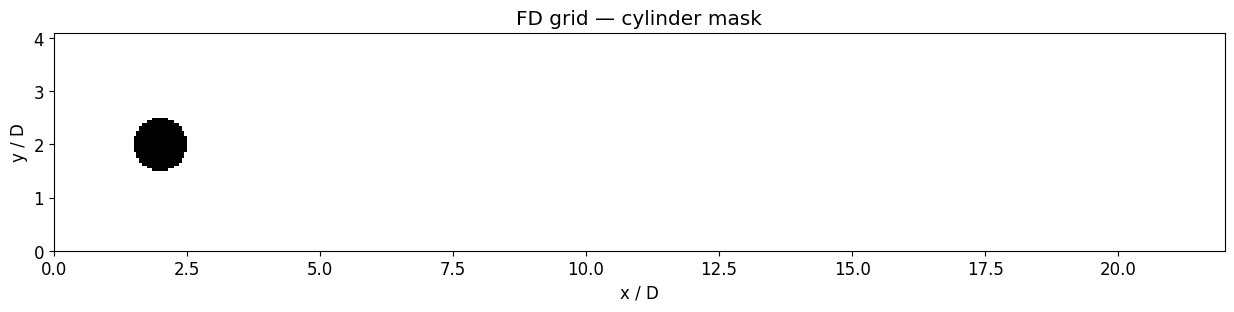

In [317]:
def create_fd_grid(Nx: int, Ny: int, cfg: CaseConfig):
    """Create staggered MAC grid arrays and cylinder mask."""
    dx = cfg.L / Nx
    dy = cfg.H / Ny

    x_p = np.linspace(dx / 2, cfg.L - dx / 2, Nx)
    y_p = np.linspace(dy / 2, cfg.H - dy / 2, Ny)
    X, Y = np.meshgrid(x_p, y_p)

    cx, cy = cfg.cyl_center
    r = cfg.cyl_radius
    mask = ((X - cx)**2 + (Y - cy)**2) < r**2

    return dx, dy, x_p, y_p, X, Y, mask


dx_t, dy_t, xp_t, yp_t, Xp_t, Yp_t, mask_t = create_fd_grid(440, 82, cfg_test)

fig, ax = plt.subplots(1, 1, figsize=(14, 3))
ax.pcolormesh(Xp_t, Yp_t, mask_t.astype(float), cmap='gray_r', shading='auto')
ax.set_aspect('equal')
ax.set_title('FD grid — cylinder mask')
ax.set_xlabel('x / D'); ax.set_ylabel('y / D')
plt.tight_layout()
plt.show()

### 1.2 FD Helper Functions

In [318]:
def laplacian_2d(f: np.ndarray, dx: float, dy: float) -> np.ndarray:
    """5-point Laplacian on interior points (Ny, Nx) array.

    Boundary rows/cols are left at zero; the caller is responsible for
    overwriting them with BCs after the diffusion step.
    """
    lap = np.zeros_like(f)
    lap[1:-1, 1:-1] = (
        (f[1:-1, 2:] - 2*f[1:-1, 1:-1] + f[1:-1, :-2]) / dx**2 +
        (f[2:, 1:-1] - 2*f[1:-1, 1:-1] + f[:-2, 1:-1]) / dy**2
    )
    return lap


def advect_upwind_vec(u: np.ndarray, v: np.ndarray,
                      dx: float, dy: float):
    """Vectorised first-order upwind advection of (u, v) by itself.

    For each momentum component, the upwind direction is determined by
    the local velocity.  This scheme is unconditionally TVD and
    introduces numerical diffusion of O(dx), which helps damp
    under-resolved features at the cost of accuracy.
    """
    adv_u = np.zeros_like(u)
    adv_v = np.zeros_like(v)

    s = slice(1, -1)

    u_pos = np.maximum(u[s, s], 0)
    u_neg = np.minimum(u[s, s], 0)
    v_pos = np.maximum(v[s, s], 0)
    v_neg = np.minimum(v[s, s], 0)

    dudx_back = (u[s, 1:-1] - u[s, :-2]) / dx
    dudx_fwd  = (u[s, 2:]   - u[s, 1:-1]) / dx
    dudy_back = (u[1:-1, s] - u[:-2, s]) / dy
    dudy_fwd  = (u[2:, s]   - u[1:-1, s]) / dy

    adv_u[s, s] = (u_pos * dudx_back + u_neg * dudx_fwd +
                   v_pos * dudy_back + v_neg * dudy_fwd)

    dvdx_back = (v[s, 1:-1] - v[s, :-2]) / dx
    dvdx_fwd  = (v[s, 2:]   - v[s, 1:-1]) / dx
    dvdy_back = (v[1:-1, s] - v[:-2, s]) / dy
    dvdy_fwd  = (v[2:, s]   - v[1:-1, s]) / dy

    adv_v[s, s] = (u_pos * dvdx_back + u_neg * dvdx_fwd +
                   v_pos * dvdy_back + v_neg * dvdy_fwd)

    return adv_u, adv_v




def advect_linear_upwind(u: np.ndarray, v: np.ndarray, dx: float, dy: float):
    """Second-order linear upwind advection (3-point upwind-biased stencil)."""
    adv_u = np.zeros_like(u)
    adv_v = np.zeros_like(v)
    s = slice(2, -2)

    uc = u[s, s]; vc = v[s, s]
    u_pos = np.maximum(uc, 0); u_neg = np.minimum(uc, 0)
    v_pos = np.maximum(vc, 0); v_neg = np.minimum(vc, 0)

    # x-direction: 3-point upwind-biased
    dudx_b = (3*u[s,2:-2] - 4*u[s,1:-3] + u[s,0:-4]) / (2*dx)
    dudx_f = (-u[s,4:]   + 4*u[s,3:-1] - 3*u[s,2:-2]) / (2*dx)
    dvdx_b = (3*v[s,2:-2] - 4*v[s,1:-3] + v[s,0:-4]) / (2*dx)
    dvdx_f = (-v[s,4:]   + 4*v[s,3:-1] - 3*v[s,2:-2]) / (2*dx)

    # y-direction: 3-point upwind-biased
    dudy_b = (3*u[2:-2,s] - 4*u[1:-3,s] + u[0:-4,s]) / (2*dy)
    dudy_f = (-u[4:,s]   + 4*u[3:-1,s] - 3*u[2:-2,s]) / (2*dy)
    dvdy_b = (3*v[2:-2,s] - 4*v[1:-3,s] + v[0:-4,s]) / (2*dy)
    dvdy_f = (-v[4:,s]   + 4*v[3:-1,s] - 3*v[2:-2,s]) / (2*dy)

    adv_u[s,s] = u_pos*dudx_b + u_neg*dudx_f + v_pos*dudy_b + v_neg*dudy_f
    adv_v[s,s] = u_pos*dvdx_b + u_neg*dvdx_f + v_pos*dvdy_b + v_neg*dvdy_f
    return adv_u, adv_v


def divergence_half(u: np.ndarray, v: np.ndarray,
                    dx: float, dy: float) -> np.ndarray:
    """Divergence using one-sided (backward) differences: consistent
    with the half-cell pressure gradient used in the projection step.

    div[j,i] = (u[j,i] - u[j,i-1])/dx + (v[j,i] - v[j-1,i])/dy

    This keeps the projection Laplacian as a compact 5-point stencil,
    avoiding the 2*dx checkerboard decoupling of central differences.
    """
    Ny, Nx = u.shape
    div = np.zeros((Ny, Nx))
    div[1:-1, 1:-1] = (
        (u[1:-1, 1:-1] - u[1:-1, :-2]) / dx +
        (v[1:-1, 1:-1] - v[:-2, 1:-1]) / dy
    )
    return div


def gradient_half(phi: np.ndarray, dx: float, dy: float):
    """Pressure gradient using one-sided (forward) differences:
    the discrete adjoint of divergence_half.

    grad_x[j,i] = (phi[j,i+1] - phi[j,i]) / dx
    grad_y[j,i] = (phi[j+1,i] - phi[j,i]) / dy

    Together with divergence_half, this ensures the composite operator
    div(grad(phi)) is the standard 5-point Laplacian on the dx grid.
    """
    Ny, Nx = phi.shape
    gx = np.zeros((Ny, Nx))
    gy = np.zeros((Ny, Nx))
    gx[:, :-1] = (phi[:, 1:] - phi[:, :-1]) / dx
    gy[:-1, :] = (phi[1:, :] - phi[:-1, :]) / dy
    return gx, gy

if HAS_NUMBA:
    @njit(parallel=True, cache=True)
    def fd_rhs_numba_no_pen(u, v, dx, dy, nu):
        """Fused upwind advection + diffusion (no penalisation).

        Returns rhs_u, rhs_v such that u_star = u + dt * rhs_u.
        Replaces three separate NumPy calls (advect + 2x laplacian) with a
        single memory pass, cutting temporary allocation overhead by ~5x.
        """
        Ny, Nx = u.shape
        rhs_u = np.zeros((Ny, Nx))
        rhs_v = np.zeros((Ny, Nx))
        idx2 = 1.0 / (dx * dx)
        idy2 = 1.0 / (dy * dy)
        for j in prange(1, Ny - 1):
            for i in range(1, Nx - 1):
                uc = u[j, i]
                vc = v[j, i]
                # Upwind advection of u
                if uc >= 0.0:
                    dudx = (uc - u[j, i - 1]) / dx
                else:
                    dudx = (u[j, i + 1] - uc) / dx
                if vc >= 0.0:
                    dudy = (uc - u[j - 1, i]) / dy
                else:
                    dudy = (u[j + 1, i] - uc) / dy
                # Upwind advection of v
                if uc >= 0.0:
                    dvdx = (vc - v[j, i - 1]) / dx
                else:
                    dvdx = (v[j, i + 1] - vc) / dx
                if vc >= 0.0:
                    dvdy = (vc - v[j - 1, i]) / dy
                else:
                    dvdy = (v[j + 1, i] - vc) / dy
                # 5-point Laplacian (diffusion)
                lap_u = ((u[j, i+1] - 2.0*uc + u[j, i-1]) * idx2
                       + (u[j+1, i] - 2.0*uc + u[j-1, i]) * idy2)
                lap_v = ((v[j, i+1] - 2.0*vc + v[j, i-1]) * idx2
                       + (v[j+1, i] - 2.0*vc + v[j-1, i]) * idy2)
                rhs_u[j, i] = -(uc * dudx + vc * dudy) + nu * lap_u
                rhs_v[j, i] = -(uc * dvdx + vc * dvdy) + nu * lap_v
        return rhs_u, rhs_v


### 1.3 Pressure Poisson Solver

In [319]:
def build_poisson_system(Nx: int, Ny: int, dx: float, dy: float, mask: np.ndarray):
    """Build the sparse matrix for the pressure Poisson equation.

    The operator is the standard 5-point Laplacian that arises from
    composing divergence_half with gradient_half.

    Boundary treatment:
      - Neumann dp/dn=0 at physical domain walls: the off-diagonal
        entry across the wall is omitted and the corresponding 1/h²
        is NOT subtracted from the diagonal.
      - Cylinder interior (mask=True): row is set to identity with
        RHS=0 → phi=0.  Neighbouring fluid cells DO include the
        masked cell as an off-diagonal entry (Dirichlet phi=0), so
        that the matrix Laplacian exactly matches div_half(grad_half).
      - One pressure reference point is pinned to zero to remove the
        constant nullspace inherent in pure-Neumann problems.
    """
    N = Nx * Ny
    idx = lambda j, i: j * Nx + i

    rows, cols, vals = [], [], []
    ref_set = False

    for j in range(Ny):
        for i in range(Nx):
            k = idx(j, i)

            if mask[j, i]:
                rows.append(k); cols.append(k); vals.append(1.0)
                continue

            if not ref_set:
                rows.append(k); cols.append(k); vals.append(1.0)
                ref_set = True
                continue

            diag = 0.0

            # For each neighbour: include as off-diagonal whether or
            # not it is a mask cell (mask cells are Dirichlet phi=0).
            # Only omit neighbours that lie OUTSIDE the domain (Neumann).
            if i > 0:
                rows.append(k); cols.append(idx(j, i-1)); vals.append(1.0 / dx**2)
                diag -= 1.0 / dx**2
            if i < Nx - 1:
                rows.append(k); cols.append(idx(j, i+1)); vals.append(1.0 / dx**2)
                diag -= 1.0 / dx**2
            if j > 0:
                rows.append(k); cols.append(idx(j-1, i)); vals.append(1.0 / dy**2)
                diag -= 1.0 / dy**2
            if j < Ny - 1:
                rows.append(k); cols.append(idx(j+1, i)); vals.append(1.0 / dy**2)
                diag -= 1.0 / dy**2

            if diag == 0.0:
                diag = 1.0
            rows.append(k); cols.append(k); vals.append(diag)

    A = sp.csr_matrix((vals, (rows, cols)), shape=(N, N))
    return A


def solve_poisson_lu(lu, rhs_2d: np.ndarray, mask: np.ndarray):
    """Apply pre-factored sparse LU (one factorisation per simulation)."""
    rhs = rhs_2d.ravel().copy()
    rhs[mask.ravel()] = 0.0
    return lu.solve(rhs).reshape(rhs_2d.shape)


### 1.4 Full FD Simulation

In [320]:
def run_fd_simulation(cfg: CaseConfig, Nx: int = 440, Ny: int = 82,
                      T_end: float = 50.0, eta: float = 1e-2,
                      cfl_safety: float = 0.25,
                      save_every_t: float = 1.0,
                      verbose: bool = True) -> Dict:
    """Chorin projection-method solver on a collocated grid.

    Key design choices (see markdown cell for full rationale):
      - Half-cell (one-sided) differences for divergence and gradient
        ensure the projection Laplacian is a compact 5-point stencil,
        preventing the checkerboard pressure decoupling that would
        arise from central (2*dx) stencils on a collocated grid.
      - Multidimensional CFL:  dt <= C / (|u|/dx + |v|/dy)
      - Diffusion limit:  dt <= dx^2 dy^2 / (4 nu (dx^2 + dy^2))
      - Penalisation treated explicitly with dt <= eta/2 stability.
      - Volume penalisation with eta=O(1e-2) balances stiffness vs
        accuracy; smaller eta gives sharper no-slip enforcement but
        requires proportionally smaller dt.
    """
    _use_numba = False   # second-order advection not yet in Numba kernel
    t_start = time.time()
    dx, dy, x_p, y_p, X, Y, mask = create_fd_grid(Nx, Ny, cfg)
    nu = cfg.nu

    u = np.zeros((Ny, Nx))
    v = np.zeros((Ny, Nx))
    p = np.zeros((Ny, Nx))

    y_arr = Y[:, 0]
    u_in = parabolic_inflow(y_arr, cfg.H)

    A_poisson = build_poisson_system(Nx, Ny, dx, dy, mask)
    lu_poisson = spla.splu(A_poisson.tocsc())

    # Initialise with parabolic profile everywhere, then project
    # to make the initial field divergence-free.  Without this step
    # the first Poisson correction is catastrophically large because
    # the raw profile has O(U/dx) divergence at the cylinder edge.
    for i in range(Nx):
        u[:, i] = u_in
    u[mask] = 0.0
    v[mask] = 0.0
    u[:, 0] = u_in
    v[:, 0] = 0.0
    u[0, :] = 0.0;  u[-1, :] = 0.0
    v[0, :] = 0.0;  v[-1, :] = 0.0
    u[:, -1] = u[:, -2]
    v[:, -1] = v[:, -2]

    div_init = divergence_half(u, v, dx, dy)
    phi_init = solve_poisson_lu(lu_poisson, div_init, mask)
    gx_init, gy_init = gradient_half(phi_init, dx, dy)
    u -= gx_init
    v -= gy_init
    u[:, 0] = u_in;  v[:, 0] = 0.0
    u[0, :] = 0.0;   u[-1, :] = 0.0
    v[0, :] = 0.0;   v[-1, :] = 0.0
    u[:, -1] = u[:, -2]; v[:, -1] = v[:, -2]
    u[mask] = 0.0;   v[mask] = 0.0

    # Break symmetry with a small localised transverse perturbation in the near-wake
    np.random.seed(42)
    _perturb = 0.05 * np.random.randn(*v.shape) * np.exp(
        -((X - cfg.cyl_center[0] - 1.0)**2 + (Y - cfg.cyl_center[1])**2) / 0.5
    )
    v += _perturb
    v[mask] = 0.0
    v[:, 0] = 0.0
    v[0, :] = 0.0
    v[-1, :] = 0.0
    del _perturb

    diag = {k: [] for k in ['time', 'CFL', 'div_before', 'div_after', 'KE',
                             'u_max', 'lift_proxy', 'drag_proxy']}
    snapshots = []
    t = 0.0
    step = 0
    next_save = save_every_t
    stable = True

    U_conv = float(np.mean(u_in))  # ≈ 1.0 nondimensional convective speed

    ke = 0.0  # initialised here; recomputed every 50 steps in diagnostics block
    if _use_numba:
        _ = fd_rhs_numba_no_pen(u.copy(), v.copy(), dx, dy, nu)  # JIT warm-up

    # Wake probe indices for lift proxy (v at a point 2 diameters downstream)
    i_probe = int((cfg.cyl_center[0] + 2.0) / dx)
    j_probe = int(cfg.cyl_center[1] / dy)

    while t < T_end:
        # --- Adaptive time-step (three constraints) ---
        u_abs_max = max(np.max(np.abs(u)), 1e-10)
        v_abs_max = max(np.max(np.abs(v)), 1e-10)

        # Multidimensional advective CFL
        dt_adv = cfl_safety / (u_abs_max / dx + v_abs_max / dy)
        # Diffusion stability (exact 2D formula)
        dt_diff = 0.25 * (dx**2 * dy**2) / (max(nu, 1e-14) * (dx**2 + dy**2))
        dt = min(dt_adv, dt_diff, 0.05)  # implicit penalisation — dt_pen constraint removed

        # --- Step 1: Tentative velocity (Numba fused kernel or NumPy fallback) ---
        if _use_numba:
            rhs_u, rhs_v = fd_rhs_numba_no_pen(u, v, dx, dy, nu)
        else:
            adv_u, adv_v = advect_linear_upwind(u, v, dx, dy)
            diff_u = laplacian_2d(u, dx, dy)
            diff_v = laplacian_2d(v, dx, dy)
            rhs_u = -adv_u + nu * diff_u
            rhs_v = -adv_v + nu * diff_v

        u_star = u + dt * rhs_u
        v_star = v + dt * rhs_v

        # Implicit penalisation: solve (1 + dt/eta)*u_star_new = u_star  =>  divide in-place.
        # Exact for a linear drag; eliminates the dt <= 0.5*eta explicit stability constraint.
        factor = 1.0 / (1.0 + dt / eta)
        u_star[mask] *= factor
        v_star[mask] *= factor

        # --- Boundary conditions on tentative velocity ---
        # Inlet: prescribed parabolic profile
        u_star[:, 0] = u_in
        v_star[:, 0] = 0.0
        # Top / bottom walls: no-slip
        u_star[0, :] = 0.0;  u_star[-1, :] = 0.0
        v_star[0, :] = 0.0;  v_star[-1, :] = 0.0
        # Outlet: 1st-order convective (Sommerfeld) — suppresses pressure-wave reflections
        u_star[:, -1] = u_star[:, -1] - dt * U_conv * (u_star[:, -1] - u_star[:, -2]) / dx
        v_star[:, -1] = v_star[:, -1] - dt * U_conv * (v_star[:, -1] - v_star[:, -2]) / dx

        # --- Step 2: Pressure Poisson equation ---
        # RHS = (1/dt) * div(u*) using backward (half-cell) differences
        div_star = divergence_half(u_star, v_star, dx, dy)
        rhs_p = div_star / dt

        phi = solve_poisson_lu(lu_poisson, rhs_p, mask)

        # --- Step 3: Velocity correction ---
        # grad(phi) using forward (half-cell) differences — adjoint of div
        grad_phi_x, grad_phi_y = gradient_half(phi, dx, dy)

        u_new = u_star - dt * grad_phi_x
        v_new = v_star - dt * grad_phi_y
        p_new = p + phi

        # --- Re-apply BCs on corrected velocity ---
        u_new[:, 0] = u_in
        v_new[:, 0] = 0.0
        u_new[0, :] = 0.0;  u_new[-1, :] = 0.0
        v_new[0, :] = 0.0;  v_new[-1, :] = 0.0
        u_new[:, -1] = u_new[:, -1] - dt * U_conv * (u_new[:, -1] - u_new[:, -2]) / dx
        v_new[:, -1] = v_new[:, -1] - dt * U_conv * (v_new[:, -1] - v_new[:, -2]) / dx
        u_new[mask] = 0.0
        v_new[mask] = 0.0

        u, v, p = u_new, v_new, p_new
        t += dt
        step += 1

        # --- Diagnostics + stability checks every 50 steps ---
        if step % 50 == 0:
            if np.any(np.isnan(u)) or np.any(np.isnan(v)):
                if verbose:
                    print(f"  [FD] NaN at t={t:.3f}, step={step}. Breaking.")
                stable = False
                break
            ke = 0.5 * np.sum(u**2 + v**2) * dx * dy
            if ke > 1e6:
                if verbose:
                    print(f"  [FD] KE blow-up ({ke:.2e}) at t={t:.3f}. Breaking.")
                stable = False
                break
            cfl_now = dt * (u_abs_max / dx + v_abs_max / dy)
            div_post = divergence_half(u, v, dx, dy)
            div_post_max = np.max(np.abs(div_post))

            j_cyl = slice(max(int((cfg.cyl_center[1] - cfg.cyl_radius) / dy), 0),
                          min(int((cfg.cyl_center[1] + cfg.cyl_radius) / dy) + 1, Ny))
            i_cyl_right = min(int((cfg.cyl_center[0] + cfg.cyl_radius) / dx) + 2, Nx - 1)
            drag_proxy = np.sum(p[j_cyl, i_cyl_right]) * dy / (0.5 * 1.0 * float(np.mean(u_in))**2 * cfg.cyl_radius * 2)

            diag['time'].append(t)
            diag['CFL'].append(cfl_now)
            diag['div_before'].append(np.max(np.abs(div_star)))
            diag['div_after'].append(div_post_max)
            diag['KE'].append(ke)
            diag['u_max'].append(u_abs_max)
            diag['lift_proxy'].append(v[j_probe, i_probe])
            diag['drag_proxy'].append(drag_proxy)

        # --- Snapshots ---
        if t >= next_save:
            snapshots.append((t, u.copy(), v.copy(), p.copy()))
            next_save += save_every_t
            if verbose:
                div_post = divergence_half(u, v, dx, dy)
                print(f"  [FD] t={t:.2f}, CFL={dt*(u_abs_max/dx+v_abs_max/dy):.3f}, "
                      f"max|div_post|={np.max(np.abs(div_post)):.2e}, "
                      f"KE={ke:.4f}, u_max={u_abs_max:.3f}")

    wall_time = time.time() - t_start
    if verbose:
        print(f"  [FD] Done: {step} steps in {wall_time:.1f}s, stable={stable}")

    return {
        'u': u, 'v': v, 'p': p,
        'X': X, 'Y': Y, 'mask': mask,
        'dx': dx, 'dy': dy,
        'snapshots': snapshots,
        'diagnostics': diag,
        'wall_time': wall_time,
        'stable': stable,
        'Nx': Nx, 'Ny': Ny,
    }

---
## 2. Finite Element Method (NGSolve)

### Approach
- **Unstructured mesh** via Netgen: exact cylinder geometry, refinement in wake
- **Taylor-Hood** P2/P1 elements: inf-sup stable velocity-pressure pair
- **IMEX Euler**: viscosity + pressure implicit, convection explicit
- **Drag/lift** via stress integration on cylinder boundary



In [321]:
try:
    import ngsolve as ngs
    from ngsolve import *
    from netgen.occ import *
    HAS_NGSOLVE = True
    print(f"NGSolve version: {ngs.__version__}")
except ImportError:
    HAS_NGSOLVE = False
    print("NGSolve not available — FEM cells will be skipped.")
    print("Install with: pip install ngsolve")

NGSolve version: 6.2.2602-2-g9a0a30704


### 2.1 Mesh Generation

In [322]:
def create_fem_mesh(cfg: CaseConfig, maxh: float = 0.2, refine_cyl: float = 0.05):
    """Create 2D mesh for channel + cylinder using Netgen OCC."""
    if not HAS_NGSOLVE:
        raise RuntimeError("NGSolve required")

    cx, cy = cfg.cyl_center
    r = cfg.cyl_radius

    channel = WorkPlane().Rectangle(cfg.L, cfg.H).Face()
    circle = WorkPlane().MoveTo(cx, cy).Circle(r).Face()
    shape = channel - circle

    shape.edges.Min(X).name = "inlet"
    shape.edges.Max(X).name = "outlet"
    shape.edges.Min(Y).name = "wall"
    shape.edges.Max(Y).name = "wall"

    for edge in shape.edges:
        if edge.name not in ("inlet", "outlet", "wall"):
            edge.name = "cyl"

    geo = OCCGeometry(shape, dim=2)
    mesh = ngs.Mesh(geo.GenerateMesh(maxh=maxh))

    return mesh


if HAS_NGSOLVE:
    mesh_test = create_fem_mesh(cfg_test, maxh=0.3)
    print(f"FEM mesh: {mesh_test.ne} elements, {mesh_test.nv} vertices")

FEM mesh: 2289 elements, 1237 vertices


### 2.2 FEM Simulation (IMEX Euler, Taylor-Hood)

In [323]:
def run_fem_simulation(cfg: CaseConfig, maxh: float = 0.15,
                       order: int = 2, T_end: float = 50.0,
                       dt: float = 0.001, save_every_t: float = 1.0,
                       verbose: bool = True) -> Dict:
    """Run FEM IMEX Euler simulation with NGSolve."""
    if not HAS_NGSOLVE:
        print("NGSolve not available, skipping FEM.")
        return {'stable': False, 'wall_time': 0, 'diagnostics': {k: [] for k in ['time','div_u','KE','lift','drag']}}

    t_start = time.time()
    mesh = create_fem_mesh(cfg, maxh=maxh)
    nu = cfg.nu

    V = VectorH1(mesh, order=order, dirichlet="inlet|wall|cyl")
    Q = H1(mesh, order=order - 1)
    X = V * Q

    (u_test, p_test), (v_test, q_test) = X.TnT()

    a = BilinearForm(X)
    a += (1/dt) * u_test * v_test * dx
    a += nu * InnerProduct(Grad(u_test), Grad(v_test)) * dx
    a += (-1) * div(v_test) * p_test * dx
    a += (-1) * div(u_test) * q_test * dx
    a.Assemble()

    gfu = GridFunction(X)
    velocity = gfu.components[0]
    pressure = gfu.components[1]

    uin_cf = CoefficientFunction(
        (4 * 1.5 * y * (cfg.H - y) / cfg.H**2, 0)
    )
    velocity.Set(uin_cf, definedon=mesh.Boundaries("inlet"))

    gfu_old = GridFunction(X)
    res = gfu.vec.CreateVector()
    inv_a = a.mat.Inverse(X.FreeDofs(), inverse="umfpack")

    mass = BilinearForm(X)
    mass += (1/dt) * u_test * v_test * dx
    mass.Assemble()

    # Define the convection form ONCE; vel_old is a reference into gfu_old,
    # so conv.Assemble() inside the loop re-evaluates with the updated velocity.
    vel_old = gfu_old.components[0]
    conv = BilinearForm(X)
    conv += (-1) * InnerProduct(Grad(u_test) * vel_old, v_test) * dx

    diag = {k: [] for k in ['time', 'div_u', 'KE', 'lift', 'drag']}
    snapshots = []
    t_cur = 0.0
    step = 0
    next_save = save_every_t
    stable = True

    while t_cur < T_end:
        gfu_old.vec.data = gfu.vec  # vel_old auto-updates as a reference into gfu_old
        conv.Assemble()

        res.data = mass.mat * gfu_old.vec + conv.mat * gfu_old.vec

        velocity.Set(uin_cf, definedon=mesh.Boundaries("inlet"))
        res.data -= a.mat * gfu.vec
        gfu.vec.data += inv_a * res

        t_cur += dt
        step += 1

        if step % max(1, int(0.5 / dt)) == 0:  # every 0.5s — 5x less mesh integration
            try:
                ke_val = Integrate(InnerProduct(velocity, velocity) * 0.5, mesh)
                div_val = Integrate(div(velocity)**2, mesh)
            except:
                stable = False
                break

            if np.isnan(ke_val) or ke_val > 1e10:
                if verbose:
                    print(f"  [FEM] Instability at t={t_cur:.3f}")
                stable = False
                break

            diag['time'].append(t_cur)
            diag['KE'].append(ke_val)
            diag['div_u'].append(np.sqrt(div_val))
            try:
                n_vec = specialcf.normal(2)
                force_cf = -pressure * Id(2) * n_vec + nu * Grad(velocity) * n_vec
                force = Integrate(force_cf, mesh, definedon=mesh.Boundaries("cyl"))
                C_D = 2.0 * force[0]
                C_L = 2.0 * force[1]
            except Exception:
                C_D, C_L = 0.0, 0.0
            diag['lift'].append(C_L)
            diag['drag'].append(C_D)

        if t_cur >= next_save:
            vel_copy = GridFunction(V)
            vel_copy.vec.data = velocity.vec
            snapshots.append((t_cur, vel_copy))
            next_save += save_every_t
            if verbose:
                try:
                    ke_val = Integrate(InnerProduct(velocity, velocity) * 0.5, mesh)
                    print(f"  [FEM] t={t_cur:.2f}, KE={ke_val:.4f}")
                except:
                    print(f"  [FEM] t={t_cur:.2f}")

    wall_time = time.time() - t_start
    if verbose:
        print(f"  [FEM] Done: {step} steps in {wall_time:.1f}s, stable={stable}")

    return {
        'mesh': mesh,
        'gfu': gfu,
        'velocity': velocity,
        'pressure': pressure,
        'diagnostics': diag,
        'snapshots': snapshots,
        'wall_time': wall_time,
        'stable': stable,
    }

---
## 3. Lattice Boltzmann Method (LBM)

### Approach
- **D2Q9** lattice with 9 discrete velocities
- **BGK (SRT)** collision: $f_i^* = f_i - \omega(f_i - f_i^{eq})$ where $\omega = 1/\tau$
- **Bounce-back** for no-slip (walls + cylinder)
- **Zou-He** inlet (velocity) / outlet (pressure)
- **Stability**: $\tau \to 0.5$ at high Re with fixed resolution

### 3.1 D2Q9 Setup & Parameter Mapping

In [324]:
class D2Q9:
    """D2Q9 lattice constants and operations."""
    c = np.array([
        [0,  0],   # 0: rest
        [1,  0],   # 1: east
        [0,  1],   # 2: north
        [-1, 0],   # 3: west
        [0, -1],   # 4: south
        [1,  1],   # 5: NE
        [-1, 1],   # 6: NW
        [-1,-1],   # 7: SW
        [1, -1],   # 8: SE
    ], dtype=int)

    w = np.array([4/9] + [1/9]*4 + [1/36]*4)

    opp = np.array([0, 3, 4, 1, 2, 7, 8, 5, 6])

    cs2 = 1.0 / 3.0

    # MRT transformation matrix (Lallemand & Luo, 2000).
    # Moment ordering: [rho, e, eps, jx, qx, jy, qy, pxx, pxy]
    # Column ordering: [rest, E, N, W, S, NE, NW, SW, SE] — matches c above.
    M = np.array([
        [ 1,  1,  1,  1,  1,  1,  1,  1,  1],   # 0: rho  (conserved)
        [-4, -1, -1, -1, -1,  2,  2,  2,  2],   # 1: e    (energy)
        [ 4, -2, -2, -2, -2,  1,  1,  1,  1],   # 2: eps  (energy square)
        [ 0,  1,  0, -1,  0,  1, -1, -1,  1],   # 3: jx   (conserved)
        [ 0, -2,  0,  2,  0,  1, -1, -1,  1],   # 4: qx   (energy flux x)
        [ 0,  0,  1,  0, -1,  1,  1, -1, -1],   # 5: jy   (conserved)
        [ 0,  0, -2,  0,  2,  1,  1, -1, -1],   # 6: qy   (energy flux y)
        [ 0,  1, -1,  1, -1,  0,  0,  0,  0],   # 7: pxx  (stress — sets viscosity)
        [ 0,  0,  0,  0,  0,  1, -1,  1, -1],   # 8: pxy  (stress — sets viscosity)
    ], dtype=float)

    M_inv = np.linalg.inv(M)


def mrt_relaxation_rates(tau: float) -> np.ndarray:
    """Diagonal relaxation-rate vector S for D2Q9 MRT.

    Moment ordering: [rho, e, eps, jx, qx, jy, qy, pxx, pxy]

    - Conserved moments (0, 3, 5): s = 0 — never relaxed.
    - Stress moments (7, 8):       s = 1/tau — matches BGK omega, sets viscosity.
    - Ghost modes (1, 2, 4, 6):    free parameters.  Values > 1/tau damp
      non-physical modes independently of the stress relaxation, giving
      the stability advantage over BGK near τ = 0.5.
    """
    s_visc  = 1.0 / tau   # stress rate = BGK omega
    s_ghost = 1.1         # aggressive ghost-mode damping (1.0–1.5 typical)
    return np.array([
        0.0,      # 0: rho   (conserved)
        s_ghost,  # 1: e     (energy — free)
        s_ghost,  # 2: eps   (energy square — free)
        0.0,      # 3: jx    (conserved)
        s_ghost,  # 4: qx    (energy flux x — free)
        0.0,      # 5: jy    (conserved)
        s_ghost,  # 6: qy    (energy flux y — free)
        s_visc,   # 7: pxx   (stress — sets viscosity, identical to BGK)
        s_visc,   # 8: pxy   (stress — sets viscosity, identical to BGK)
    ])


def lattice_params(Re: float, D_lat: int = 40, U_lat: float = 0.04):
    """Map physical Re to lattice parameters."""
    cs2 = D2Q9.cs2
    nu_lat = U_lat * D_lat / Re
    tau = 0.5 + nu_lat / cs2
    Ma = U_lat / np.sqrt(cs2)
    omega = 1.0 / tau

    H_over_D = 4.1
    L_over_D = 22.0
    Ny = int(H_over_D * D_lat) + 1
    Nx = int(L_over_D * D_lat) + 1

    return {
        'nu_lat': nu_lat, 'tau': tau, 'Ma': Ma, 'omega': omega,
        'Nx': Nx, 'Ny': Ny, 'D_lat': D_lat, 'U_lat': U_lat,
        'S_mrt': mrt_relaxation_rates(tau),
    }


p_test = lattice_params(100, D_lat=40)
print(f"Re=100: τ={p_test['tau']:.4f}, Ma={p_test['Ma']:.4f}, "
      f"grid={p_test['Nx']}×{p_test['Ny']}")

Re=100: τ=0.5480, Ma=0.0693, grid=881×165


### 3.2 Equilibrium, Collision, Streaming

In [325]:
def feq_d2q9(rho, ux, uy):
    """Equilibrium distribution for D2Q9 — fully vectorized (no Python loop)."""
    c   = D2Q9.c    # (9, 2)
    w   = D2Q9.w    # (9,)
    cs2 = D2Q9.cs2
    cu  = (c[:, 0, None, None] * ux[None, :, :]
         + c[:, 1, None, None] * uy[None, :, :])   # (9, Ny, Nx)
    usq = ux**2 + uy**2                             # (Ny, Nx)
    return (w[:, None, None] * rho[None, :, :]
            * (1.0 + cu / cs2
               + cu**2 / (2.0 * cs2**2)
               - usq[None, :, :] / (2.0 * cs2)))


def collide_bgk(f, feq, omega):
    """BGK collision (kept for fallback path)."""
    return f - omega * (f - feq)


def collide_mrt(f, rho, ux, uy, S_diag, M, M_inv):
    """MRT collision operator for D2Q9 (NumPy, vectorized over all nodes).

    Steps:
      1. Transform f → moment space: m = M @ f_flat
      2. Build equilibrium moments meq analytically from rho, ux, uy
      3. Relax each moment independently: m -= S * (m - meq)
      4. Transform back: f_post = M_inv @ m

    Parameters
    ----------
    f      : (9, Ny, Nx) distribution functions
    rho    : (Ny, Nx) density
    ux, uy : (Ny, Nx) velocity
    S_diag : (9,) relaxation rates (from mrt_relaxation_rates)
    M      : (9, 9) transformation matrix  (D2Q9.M)
    M_inv  : (9, 9) inverse                (D2Q9.M_inv)

    Returns
    -------
    f_post : (9, Ny, Nx)
    """
    Ny, Nx = rho.shape
    f_flat   = f.reshape(9, -1)               # (9, Ny*Nx)
    m        = M @ f_flat                      # (9, Ny*Nx) — moment space

    # Equilibrium moments (analytical; faster than transforming feq)
    rho_f = rho.ravel()
    ux_f  = ux.ravel()
    uy_f  = uy.ravel()
    usq   = ux_f**2 + uy_f**2

    meq = np.empty_like(m)
    meq[0] = rho_f
    meq[1] = rho_f * (-2.0 + 3.0 * usq)
    meq[2] = rho_f * ( 1.0 - 3.0 * usq)
    meq[3] = rho_f * ux_f
    meq[4] = -rho_f * ux_f
    meq[5] = rho_f * uy_f
    meq[6] = -rho_f * uy_f
    meq[7] = rho_f * (ux_f**2 - uy_f**2)
    meq[8] = rho_f * ux_f * uy_f

    # Relax each moment at its own rate (vectorized broadcast)
    m -= S_diag[:, None] * (m - meq)          # (9, Ny*Nx)

    return (M_inv @ m).reshape(9, Ny, Nx)

def stream_d2q9(f):
    """Stream distributions using slice assignment — 2x faster than np.roll."""
    f_new = np.empty_like(f)
    f_new[0] = f[0]                               # rest

    # Axis-aligned (E/N/W/S)
    f_new[1, :, 1:]  = f[1, :, :-1];  f_new[1, :, 0]   = f[1, :, -1]   # E  (+x)
    f_new[2, 1:, :]  = f[2, :-1, :];  f_new[2, 0, :]   = f[2, -1, :]   # N  (+y)
    f_new[3, :, :-1] = f[3, :, 1:];   f_new[3, :, -1]  = f[3, :, 0]    # W  (-x)
    f_new[4, :-1, :] = f[4, 1:, :];   f_new[4, -1, :]  = f[4, 0, :]    # S  (-y)

    # Diagonal (NE/NW/SW/SE)
    f_new[5, 1:, 1:]   = f[5, :-1, :-1]; f_new[5, 0, :] = f[5, -1, :]; f_new[5, :, 0]  = f[5, :, -1]  # NE
    f_new[6, 1:, :-1]  = f[6, :-1, 1:];  f_new[6, 0, :] = f[6, -1, :]; f_new[6, :, -1] = f[6, :, 0]   # NW
    f_new[7, :-1, :-1] = f[7, 1:, 1:];   f_new[7, -1,:] = f[7, 0, :];  f_new[7, :, -1] = f[7, :, 0]   # SW
    f_new[8, :-1, 1:]  = f[8, 1:, :-1];  f_new[8, -1,:] = f[8, 0, :];  f_new[8, :, 0]  = f[8, :, -1]  # SE

    return f_new


def macro_vars(f):
    """Macroscopic density and velocity — vectorized."""
    c   = D2Q9.c
    rho = f.sum(axis=0)
    ux  = (f * c[:, 0, None, None]).sum(axis=0) / rho
    uy  = (f * c[:, 1, None, None]).sum(axis=0) / rho
    return rho, ux, uy


In [326]:
# ── Numba fused collide-stream-macro kernel ───────────────────────────────────
# Processes every lattice node in a single pass: no temporaries, cache-friendly.
# prange parallelises over rows (j); no race conditions — streaming is a bijection
# so each f_new[k, jj, ii] is written by exactly one (k, j, i) source node.

if HAS_NUMBA:
    @njit(parallel=True, cache=True)
    def lbm_step_numba(f, omega, Ny, Nx, c, w, cs2):
        """Fused BGK collide + stream + macro in one pass (Numba JIT).

        Parameters
        ----------
        f     : (9, Ny, Nx) distribution array
        omega : relaxation frequency  1/tau
        c     : (9, 2) int64 lattice velocity vectors
        w     : (9,)   float64 lattice weights
        cs2   : float  lattice speed-of-sound squared (1/3)

        Returns
        -------
        f_new, rho, ux, uy  — post-stream distributions + macro fields
        """
        f_new = np.empty_like(f)
        rho   = np.empty((Ny, Nx))
        ux    = np.empty((Ny, Nx))
        uy    = np.empty((Ny, Nx))

        for j in prange(Ny):
            for i in range(Nx):
                # ── Macro ────────────────────────────────────────────────────
                r = 0.0;  vx = 0.0;  vy = 0.0
                for k in range(9):
                    fki = f[k, j, i]
                    r  += fki
                    vx += fki * c[k, 0]
                    vy += fki * c[k, 1]
                vx /= r;  vy /= r
                rho[j, i] = r;  ux[j, i] = vx;  uy[j, i] = vy

                # ── Equilibrium, collision, stream ───────────────────────────
                usq = vx * vx + vy * vy
                for k in range(9):
                    cu    = c[k, 0] * vx + c[k, 1] * vy
                    feq_k = w[k] * r * (1.0 + cu / cs2
                                        + cu * cu / (2.0 * cs2 * cs2)
                                        - usq / (2.0 * cs2))
                    f_post = f[k, j, i] - omega * (f[k, j, i] - feq_k)

                    # Periodic wrap — BCs will overwrite walls/inlet/outlet
                    jj = j + c[k, 1]
                    ii = i + c[k, 0]
                    if   jj < 0:    jj = Ny - 1
                    elif jj >= Ny:  jj = 0
                    if   ii < 0:    ii = Nx - 1
                    elif ii >= Nx:  ii = 0
                    f_new[k, jj, ii] = f_post

        return f_new, rho, ux, uy


    @njit(parallel=True, cache=True)
    def collide_mrt_numba(f, rho, ux, uy, S_diag, M, M_inv, Ny, Nx):
        """Fused MRT collision — one node at a time, no temporaries.

        prange over rows is safe: each (k, j, i) reads and writes
        independent elements of f (collision is a local operation).
        """
        f_post = np.empty_like(f)
        for j in prange(Ny):
            for i in range(Nx):
                r  = rho[j, i]
                vx = ux[j, i]
                vy = uy[j, i]
                usq = vx * vx + vy * vy

                # Local f vector
                fl = np.empty(9)
                for k in range(9):
                    fl[k] = f[k, j, i]

                # Transform to moment space: ml = M @ fl
                ml = np.zeros(9)
                for k in range(9):
                    for q in range(9):
                        ml[k] += M[k, q] * fl[q]

                # Equilibrium moments
                meq = np.empty(9)
                meq[0] = r
                meq[1] = r * (-2.0 + 3.0 * usq)
                meq[2] = r * ( 1.0 - 3.0 * usq)
                meq[3] = r * vx
                meq[4] = -r * vx
                meq[5] = r * vy
                meq[6] = -r * vy
                meq[7] = r * (vx * vx - vy * vy)
                meq[8] = r * vx * vy

                # Relax each moment independently
                for k in range(9):
                    ml[k] -= S_diag[k] * (ml[k] - meq[k])

                # Transform back: f_post[:, j, i] = M_inv @ ml
                for k in range(9):
                    val = 0.0
                    for q in range(9):
                        val += M_inv[k, q] * ml[q]
                    f_post[k, j, i] = val

        return f_post

else:
    # Placeholders so names are always defined — run_lbm_simulation checks HAS_NUMBA
    def lbm_step_numba(f, omega, Ny, Nx, c, w, cs2):
        raise RuntimeError("Numba not available.")
    def collide_mrt_numba(f, rho, ux, uy, S_diag, M, M_inv, Ny, Nx):
        raise RuntimeError("Numba not available.")



### 3.3 Boundary Conditions

In [327]:
def apply_lbm_bcs(f, mask, ux_in, Nx, Ny):
    """Apply bounce-back + Zou-He BCs."""
    opp = D2Q9.opp
    w = D2Q9.w

    # --- Bounce-back on cylinder (copy first to avoid overwrite corruption) ---
    f_temp = f[:, mask].copy()
    for i in range(9):
        f[opp[i], mask] = f_temp[i]

    # --- Top wall (no-slip bounce-back) ---
    f[4, -1, :] = f[2, -1, :]
    f[7, -1, :] = f[5, -1, :]
    f[8, -1, :] = f[6, -1, :]

    # --- Bottom wall ---
    f[2, 0, :] = f[4, 0, :]
    f[5, 0, :] = f[7, 0, :]
    f[6, 0, :] = f[8, 0, :]

    # --- Zou-He velocity inlet (x=0) ---
    rho_in = (f[0, :, 0] + f[2, :, 0] + f[4, :, 0] +
              2 * (f[3, :, 0] + f[6, :, 0] + f[7, :, 0])) / (1.0 - ux_in)
    f[1, :, 0] = f[3, :, 0] + (2.0/3.0) * rho_in * ux_in
    f[5, :, 0] = f[7, :, 0] + (1.0/6.0) * rho_in * ux_in - 0.5 * (f[2, :, 0] - f[4, :, 0])
    f[8, :, 0] = f[6, :, 0] + (1.0/6.0) * rho_in * ux_in + 0.5 * (f[2, :, 0] - f[4, :, 0])

    # --- Zou-He pressure outlet (x=Nx-1, ρ=1) ---
    rho_out = 1.0
    ux_out = -1.0 + (f[0, :, -1] + f[2, :, -1] + f[4, :, -1] +
                      2 * (f[1, :, -1] + f[5, :, -1] + f[8, :, -1])) / rho_out
    f[3, :, -1] = f[1, :, -1] - (2.0/3.0) * rho_out * ux_out
    f[7, :, -1] = f[5, :, -1] - (1.0/6.0) * rho_out * ux_out + 0.5 * (f[2, :, -1] - f[4, :, -1])
    f[6, :, -1] = f[8, :, -1] - (1.0/6.0) * rho_out * ux_out - 0.5 * (f[2, :, -1] - f[4, :, -1])

    return f

### 3.4 Full LBM Simulation

In [328]:
def compute_lbm_forces(f, mask):
    """Momentum-exchange method: net drag/lift force on the cylinder.

    After bounce-back, the momentum transferred at each boundary link
    c_i equals f_i(x_b) + f_{opp_i}(x_b).  Summing over all boundary
    fluid nodes gives the total hydrodynamic force on the solid.
    """
    c   = D2Q9.c
    opp = D2Q9.opp
    Fx, Fy = 0.0, 0.0
    for i in range(1, 9):  # skip rest direction (i=0)
        cx_i, cy_i = int(c[i, 0]), int(c[i, 1])
        # Fluid nodes whose i-th lattice neighbour is inside the solid
        shifted  = np.roll(np.roll(mask, -cx_i, axis=1), -cy_i, axis=0)
        boundary = shifted & (~mask)
        oi = opp[i]
        Fx += float(np.sum((f[i][boundary] + f[oi][boundary]) * c[i, 0]))
        Fy += float(np.sum((f[i][boundary] + f[oi][boundary]) * c[i, 1]))
    return Fx, Fy



def run_lbm_simulation(cfg: CaseConfig, D_lat: int = 40,
                       U_lat: float = 0.04, T_star: float = 50.0,
                       collision: str = 'bgk',
                       save_every_t: float = 1.0,
                       verbose: bool = True) -> Dict:
    """Run LBM D2Q9 simulation with BGK or MRT collision."""
    t_start_wall = time.time()
    params   = lattice_params(cfg.Re, D_lat, U_lat)
    Nx       = params['Nx']
    Ny       = params['Ny']
    tau      = params['tau']
    omega    = params['omega']
    nu_lat   = params['nu_lat']

    if verbose:
        print(f"  [LBM-{collision.upper()}] Re={cfg.Re}, τ={tau:.4f}, "
              f"Ma={params['Ma']:.4f}, grid={Nx}×{Ny}")
    if tau < 0.505 and collision == 'bgk' and verbose:
        print(f"  [LBM] WARNING: τ={tau:.6f} near 0.5, BGK likely unstable. "
              "Try collision='mrt'.")

    cx_lat = cfg.cyl_center[0] * D_lat
    cy_lat = cfg.cyl_center[1] * D_lat
    r_lat  = cfg.cyl_radius * D_lat

    yy, xx = np.meshgrid(np.arange(Ny), np.arange(Nx), indexing='ij')
    mask   = ((xx - cx_lat)**2 + (yy - cy_lat)**2) < r_lat**2

    y_phys       = np.arange(Ny) / D_lat
    ux_in_profile = U_lat * parabolic_inflow(y_phys, cfg.H)

    rho   = np.ones((Ny, Nx))
    ux_ic = np.zeros((Ny, Nx))
    uy_ic = np.zeros((Ny, Nx))
    for j in range(Ny):
        ux_ic[j, :] = ux_in_profile[j]
    ux_ic[mask] = 0.0;  uy_ic[mask] = 0.0
    f = feq_d2q9(rho, ux_ic, uy_ic)

    T_lat             = int(T_star * D_lat / U_lat)
    save_interval_lat = max(1, int(save_every_t * D_lat / U_lat))

    # Plain typed arrays for Numba (cannot access class attributes inside @njit)
    c_arr = np.array(D2Q9.c, dtype=np.int64)
    w_arr = np.array(D2Q9.w, dtype=np.float64)
    cs2   = float(D2Q9.cs2)

    # MRT pre-computation (only when using MRT)
    S_mrt = None
    M     = None
    M_inv = None
    if collision == 'mrt':
        S_mrt = params['S_mrt']
        M     = D2Q9.M.copy()
        M_inv = D2Q9.M_inv.copy()
        if verbose:
            print(f"  [LBM-MRT] s_visc={S_mrt[7]:.4f}, s_ghost={S_mrt[1]:.4f}")

    if HAS_NUMBA:
        if verbose:
            print("  [LBM] Warming up JIT (first call triggers compilation)...")
        _f_tmp = f.copy()
        if collision == 'bgk':
            _ = lbm_step_numba(_f_tmp, omega, Ny, Nx, c_arr, w_arr, cs2)
        else:
            _rho_tmp, _ux_tmp, _uy_tmp = macro_vars(_f_tmp)
            _ = collide_mrt_numba(_f_tmp, _rho_tmp, _ux_tmp, _uy_tmp,
                                  S_mrt, M, M_inv, Ny, Nx)
        if verbose:
            print("  [LBM] JIT ready.")

    diag = {k: [] for k in ['time_star', 'KE', 'max_rho_dev', 'lift_proxy', 'drag_proxy']}
    snapshots = []
    stable    = True
    log_every = max(1, T_lat // 200)
    # Keep current rho/ux/uy in scope for diagnostics (updated by Numba path)
    rho = np.ones((Ny, Nx))
    ux  = ux_ic.copy()
    uy  = uy_ic.copy()

    for step in range(T_lat):
        # ── Macroscopic variables + Collision + Stream ───────────────────────
        if collision == 'bgk' and HAS_NUMBA:
            # Fastest path: fused BGK + stream in one Numba pass
            f, rho, ux, uy = lbm_step_numba(f, omega, Ny, Nx, c_arr, w_arr, cs2)
        else:
            rho, ux, uy = macro_vars(f)
            if collision == 'mrt':
                if HAS_NUMBA:
                    f = collide_mrt_numba(f, rho, ux, uy, S_mrt, M, M_inv, Ny, Nx)
                else:
                    f = collide_mrt(f, rho, ux, uy, S_mrt, M, M_inv)
            else:  # bgk, no Numba
                feq = feq_d2q9(rho, ux, uy)
                f   = collide_bgk(f, feq, omega)
            f = stream_d2q9(f)

        # ── Boundary conditions ───────────────────────────────────────────────
        f = apply_lbm_bcs(f, mask, ux_in_profile, Nx, Ny)

        # ── Stability check (every 100 steps — avoid per-step overhead) ───────
        if step % 100 == 0:
            if np.any(np.isnan(f)) or np.any(rho < 0):
                if verbose:
                    print(f"  [LBM] NaN/ρ<0 at t*={step * U_lat / D_lat:.2f}. Stopping.")
                stable = False
                break

        # ── Diagnostics ───────────────────────────────────────────────────────
        if step % log_every == 0:
            t_star_val  = step * U_lat / D_lat
            ke          = 0.5 * float(np.sum(ux**2 + uy**2))
            max_rho_dev = float(np.max(np.abs(rho - 1.0)))

            Fx, Fy = compute_lbm_forces(f, mask)
            ref    = max(0.5 * U_lat**2 * D_lat, 1e-15)
            drag_p = Fx / ref
            lift_p = Fy / ref

            diag['time_star'].append(t_star_val)
            diag['KE'].append(ke)
            diag['max_rho_dev'].append(max_rho_dev)
            diag['lift_proxy'].append(lift_p)
            diag['drag_proxy'].append(drag_p)

        # ── Snapshots ─────────────────────────────────────────────────────────
        if step % save_interval_lat == 0 and step > 0:
            t_star_val = step * U_lat / D_lat
            snapshots.append((t_star_val, rho.copy(), ux.copy(), uy.copy()))
            if verbose:
                print(f"  [LBM] t*={t_star_val:.2f}, "
                      f"max|ρ-1|={np.max(np.abs(rho-1.0)):.2e}, "
                      f"KE={0.5*np.sum(ux**2+uy**2):.1f}")

    rho, ux, uy = macro_vars(f)
    wall_time   = time.time() - t_start_wall
    if verbose:
        print(f"  [LBM] Done: {step+1} steps in {wall_time:.1f}s "
              f"({wall_time/(step+1)*1000:.2f} ms/step), stable={stable}")

    x_phys     = np.arange(Nx) / D_lat
    y_phys_out = np.arange(Ny) / D_lat
    X_phys, Y_phys = np.meshgrid(x_phys, y_phys_out)

    return {
        'rho': rho, 'ux': ux / U_lat, 'uy': uy / U_lat,
        'X': X_phys, 'Y': Y_phys, 'mask': mask,
        'snapshots': snapshots,
        'diagnostics': diag,
        'params': params,
        'wall_time': wall_time,
        'stable': stable,
        'Nx': Nx, 'Ny': Ny,
        'collision': collision,
    }


---
## 4. Shared Post-Processing

### 4.1 Vorticity

In [329]:
def compute_vorticity(u, v, dx, dy):
    """ω = ∂v/∂x − ∂u/∂y.

    Interior: central differences.  Boundaries: one-sided (2nd-order
    biased) so edge rows/columns are not filled with artificial zeros
    from “missing neighbours” — that was a main source of blocky inlet
    artefacts in plots.

    Note: a **parabolic** inlet u(y) with v = 0 has ω = −∂u/∂y ≠ 0
    (shear in the approach flow).  That is physical, not a bug.
    """
    dvdx = np.zeros_like(u)
    dudy = np.zeros_like(u)
    dvdx[:, 1:-1] = (v[:, 2:] - v[:, :-2]) / (2 * dx)
    dvdx[:, 0] = (v[:, 1] - v[:, 0]) / dx
    dvdx[:, -1] = (v[:, -1] - v[:, -2]) / dx
    dudy[1:-1, :] = (u[2:, :] - u[:-2, :]) / (2 * dy)
    dudy[0, :] = (u[1, :] - u[0, :]) / dy
    dudy[-1, :] = (u[-1, :] - u[-2, :]) / dy
    return dvdx - dudy


In [330]:
def extract_strouhal(times, lift_signal, transient_fraction=0.3):
    """Extract Strouhal number from a lift/drag time-series via FFT.

    Parameters
    ----------
    times              : array-like of sample times
    lift_signal        : array-like of lift (or proxy) values
    transient_fraction : fraction of signal discarded as initial transient

    Returns
    -------
    St       : Strouhal number  St = f_peak · D / U  (D=1, U=1 → St = f_peak)
    f_peak   : dominant shedding frequency [1/simulation time]
    freq     : full frequency array (for plotting)
    fft_mag  : full FFT magnitude array (for plotting)
    """
    n_start = int(len(times) * transient_fraction)
    t   = np.asarray(times[n_start:], dtype=float)
    sig = np.asarray(lift_signal[n_start:], dtype=float)

    if len(t) < 10:
        return None, None, None, None

    dt_mean = float(np.mean(np.diff(t)))
    freq    = np.fft.rfftfreq(len(sig), d=dt_mean)
    fft_mag = np.abs(np.fft.rfft(sig - sig.mean()))

    if len(fft_mag) < 2:
        return None, None, None, None

    peak_idx = int(np.argmax(fft_mag[1:])) + 1   # skip DC component
    f_peak   = float(freq[peak_idx])
    St       = f_peak   # nondimensional: D=1, U_mean=1

    return St, f_peak, freq, fft_mag


### 4.2 Plotting Utilities

In [331]:
def plot_velocity_field(X, Y, u, v, title='', mask=None, cfg=None):
    """Plot |u| colour map with streamlines."""
    speed = np.sqrt(u**2 + v**2)
    fig, ax = plt.subplots(1, 1, figsize=(16, 4))
    pcm = ax.pcolormesh(X, Y, speed, cmap='viridis', shading='auto')
    plt.colorbar(pcm, ax=ax, label='|u|')
    if mask is not None:
        ax.contour(X, Y, mask.astype(float), levels=[0.5], colors='red', linewidths=2)
    if cfg is not None:
        circ = MplCircle(cfg.cyl_center, cfg.cyl_radius, fill=True, fc='gray', ec='red', lw=2)
        ax.add_patch(circ)
    try:
        ax.streamplot(X[0, :], Y[:, 0], u, v, color='white', linewidth=0.5, density=1.5)
    except:
        pass
    ax.set_aspect('equal')
    ax.set_xlabel('x / D')
    ax.set_ylabel('y / D')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_vorticity(X, Y, omega, title='', mask=None, cfg=None, clim=None,
                   interior_margin=3):
    """Plot vorticity contours.

    interior_margin: trim this many cells from each side when choosing
    symmetric colour limits from percentiles, so the inlet shear strip
    does not dominate vmin/vmax and wash out the wake.
    """
    fig, ax = plt.subplots(1, 1, figsize=(16, 4))
    if clim is not None:
        vmax = clim
    else:
        Ny, Nx = omega.shape
        j0, j1 = interior_margin, max(Ny - interior_margin, interior_margin + 1)
        i0, i1 = interior_margin, max(Nx - interior_margin, interior_margin + 1)
        w = omega[j0:j1, i0:i1]
        vmax = max(abs(np.nanpercentile(w, 2)), abs(np.nanpercentile(w, 98)))
        if vmax < 1e-12:
            vmax = max(abs(np.nanpercentile(omega, 2)), abs(np.nanpercentile(omega, 98)))
    pcm = ax.pcolormesh(X, Y, omega, cmap='RdBu_r', shading='auto',
                        vmin=-vmax, vmax=vmax)
    plt.colorbar(pcm, ax=ax, label='ω')
    if cfg is not None:
        circ = MplCircle(cfg.cyl_center, cfg.cyl_radius, fill=True, fc='gray', ec='k', lw=2)
        ax.add_patch(circ)
    ax.set_aspect('equal')
    ax.set_xlabel('x / D')
    ax.set_ylabel('y / D')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_fem_velocity_field(res, cfg, title='', nx=160, ny=60):
    """Sample NGSolve |u| on a regular grid and plot (matplotlib).

    FEM results are on an unstructured mesh, so FD/LBM plotting helpers
    cannot be reused without interpolation.
    """
    if not globals().get('HAS_NGSOLVE', False) or 'mesh' not in res:
        print('FEM plot: NGSolve not available or no mesh in result.')
        return
    import ngsolve as ngs
    mesh = res['mesh']
    vel = res['velocity']
    speed = ngs.sqrt(ngs.InnerProduct(vel, vel))
    xs = np.linspace(0, cfg.L, nx)
    ys = np.linspace(0, cfg.H, ny)
    XX, YY = np.meshgrid(xs, ys)
    Z = np.zeros_like(XX)
    for j in range(ny):
        for i in range(nx):
            try:
                mp = mesh(XX[j, i], YY[j, i])
                Z[j, i] = float(speed(mp))
            except Exception:
                Z[j, i] = np.nan
    fig, ax = plt.subplots(1, 1, figsize=(16, 4))
    pcm = ax.pcolormesh(XX, YY, Z, cmap='viridis', shading='auto')
    plt.colorbar(pcm, ax=ax, label='|u|')
    circ = MplCircle(cfg.cyl_center, cfg.cyl_radius, fill=True, fc='gray', ec='red', lw=2)
    ax.add_patch(circ)
    ax.set_aspect('equal')
    ax.set_xlabel('x / D')
    ax.set_ylabel('y / D')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_fem_vorticity(res, cfg, title='', nx=160, ny=60, interior_margin=3):
    """2D vorticity ω = ∂v/∂x − ∂u/∂y from the FE velocity field."""
    if not globals().get('HAS_NGSOLVE', False) or 'mesh' not in res:
        print('FEM plot: NGSolve not available or no mesh in result.')
        return
    import ngsolve as ngs
    mesh = res['mesh']
    vel = res['velocity']
    # ω = ∂v/∂x − ∂u/∂y; VectorH1 has no curl() — use Jacobian Grad(vel)[i,j] = ∂(vel_i)/∂(x_j)
    g = ngs.Grad(vel)
    omega = g[1, 0] - g[0, 1]
    xs = np.linspace(0, cfg.L, nx)
    ys = np.linspace(0, cfg.H, ny)
    XX, YY = np.meshgrid(xs, ys)
    Z = np.zeros_like(XX)
    for j in range(ny):
        for i in range(nx):
            try:
                mp = mesh(XX[j, i], YY[j, i])
                Z[j, i] = float(omega(mp))
            except Exception:
                Z[j, i] = np.nan
    j0, j1 = interior_margin, max(ny - interior_margin, interior_margin + 1)
    i0, i1 = interior_margin, max(nx - interior_margin, interior_margin + 1)
    w = Z[j0:j1, i0:i1]
    vmax = max(abs(np.nanpercentile(w, 2)), abs(np.nanpercentile(w, 98)))
    if vmax < 1e-12:
        vmax = max(abs(np.nanpercentile(Z, 2)), abs(np.nanpercentile(Z, 98)))
    fig, ax = plt.subplots(1, 1, figsize=(16, 4))
    pcm = ax.pcolormesh(XX, YY, Z, cmap='RdBu_r', shading='auto',
                        vmin=-vmax, vmax=vmax)
    plt.colorbar(pcm, ax=ax, label='ω')
    circ = MplCircle(cfg.cyl_center, cfg.cyl_radius, fill=True, fc='gray', ec='k', lw=2)
    ax.add_patch(circ)
    ax.set_aspect('equal')
    ax.set_xlabel('x / D')
    ax.set_ylabel('y / D')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


In [332]:
def plot_diagnostics(results_dict, title_prefix=""):
    """Overlay KE, lift, incompressibility, and Strouhal spectra for all methods.

    Parameters
    ----------
    results_dict : dict  {method_name: result_dict}
        Keys can be 'FD', 'FEM', 'LBM'.
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f"{title_prefix} Diagnostics", fontsize=13)
    colors = {'FD': 'steelblue', 'FEM': 'darkorange', 'LBM': 'forestgreen'}

    for method, res in results_dict.items():
        diag  = res.get('diagnostics', {})
        color = colors.get(method, 'gray')
        t     = diag.get('time_star' if method == 'LBM' else 'time', [])
        ke    = diag.get('KE', [])
        lift  = diag.get('lift_proxy' if method == 'LBM' else 'lift', [])

        if t and ke:
            axes[0, 0].plot(t, ke,   label=method, color=color)
        if t and lift:
            axes[0, 1].plot(t, lift, label=method, color=color)

        # Incompressibility / compressibility
        if method == 'FD':
            da = diag.get('div_after', [])
            if t and da:
                axes[0, 2].semilogy(t, da, label='FD ‖∇·u‖∞', color=color)
        elif method == 'FEM':
            du = diag.get('div_u', [])
            tf = diag.get('time', [])
            if tf and du:
                axes[0, 2].semilogy(tf, du, label='FEM ‖∇·u‖L2', color=color)
        elif method == 'LBM':
            rd = diag.get('max_rho_dev', [])
            if t and rd:
                axes[1, 2].semilogy(t, rd, label='LBM max|ρ-1|', color=color)

        # Strouhal FFT
        if len(t) > 10 and len(lift) > 10:
            St, f_pk, freq, fft_mag = extract_strouhal(t, lift)
            if St is not None and max(fft_mag) > 0:
                axes[1, 0].plot(freq, fft_mag / max(fft_mag),
                                label=f"{method} St={St:.3f}", color=color)
                axes[1, 0].axvline(f_pk, ls='--', color=color, alpha=0.5)

    axes[0, 0].set(xlabel="t", ylabel="KE",    title="Kinetic Energy"); axes[0, 0].legend()
    axes[0, 1].set(xlabel="t", ylabel="C_L",   title="Lift Coefficient"); axes[0, 1].legend()
    axes[0, 2].set(xlabel="t", ylabel="‖∇·u‖", title="Incompressibility (FD/FEM)"); axes[0, 2].legend()
    axes[1, 0].set(xlabel="f", ylabel="|FFT| norm.", title="Lift Spectrum (Strouhal)",
                   xlim=(0, 1.0)); axes[1, 0].legend()
    axes[1, 2].set(xlabel="t*", ylabel="max|ρ-1|", title="Compressibility Error (LBM)"); axes[1, 2].legend()
    axes[1, 1].axis('off')
    plt.tight_layout(); plt.show()


---
## 5. Validation (all three methods)

At $Re=20$ (steady wake): **FD**, **FEM** (if NGSolve), **LBM** — same case, comparable wall times via modest grids. 


=== FD Re=20 ===
  [FD] t=1.00, CFL=0.250, max|div_post|=9.27e+00, KE=51.8593, u_max=1.919
  [FD] t=2.00, CFL=0.250, max|div_post|=9.70e+00, KE=50.6956, u_max=1.880
  [FD] t=3.00, CFL=0.250, max|div_post|=1.01e+01, KE=48.1684, u_max=1.802
  [FD] t=4.01, CFL=0.250, max|div_post|=1.05e+01, KE=45.4808, u_max=1.733
  [FD] t=5.01, CFL=0.250, max|div_post|=1.08e+01, KE=42.7458, u_max=1.690
  [FD] t=6.01, CFL=0.250, max|div_post|=1.11e+01, KE=41.3901, u_max=1.653
  [FD] t=7.01, CFL=0.250, max|div_post|=1.15e+01, KE=38.7267, u_max=1.613
  [FD] t=8.01, CFL=0.250, max|div_post|=1.18e+01, KE=37.4233, u_max=1.574
  [FD] t=9.01, CFL=0.250, max|div_post|=1.21e+01, KE=34.8812, u_max=1.537
  [FD] t=10.01, CFL=0.250, max|div_post|=1.24e+01, KE=33.6435, u_max=1.501
  [FD] t=11.01, CFL=0.250, max|div_post|=1.26e+01, KE=32.4329, u_max=1.499
  [FD] t=12.01, CFL=0.250, max|div_post|=1.29e+01, KE=31.2655, u_max=1.499
  [FD] Done: 948 steps in 0.5s, stable=True


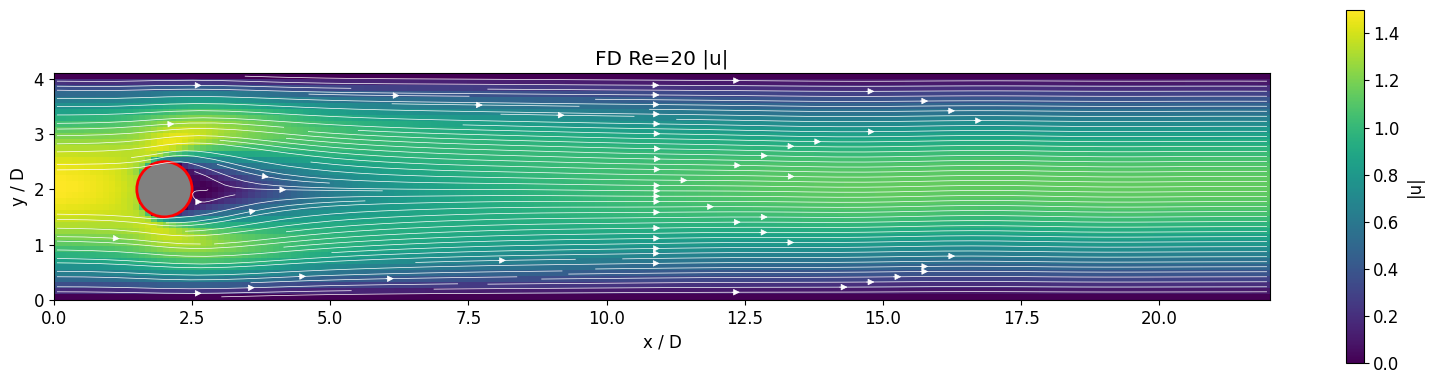

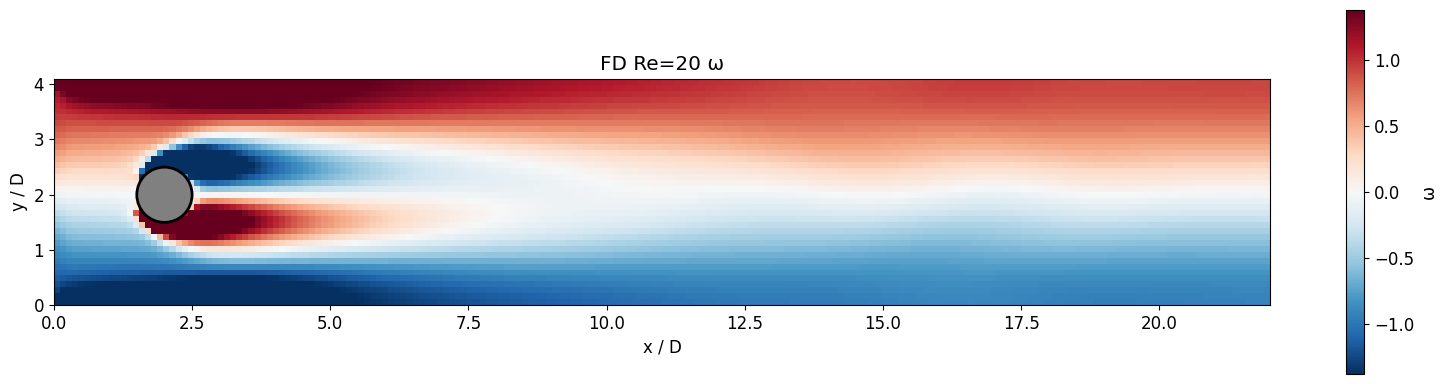

=== FEM Re=20 ===
  [FEM] t=1.00, KE=50.2617
  [FEM] t=2.00, KE=51.8555
  [FEM] t=3.00, KE=52.7970
  [FEM] t=4.00, KE=53.3926
  [FEM] t=5.02, KE=53.7973
  [FEM] t=6.02, KE=54.0697
  [FEM] t=7.02, KE=54.2591
  [FEM] t=8.02, KE=54.3901
  [FEM] Done: 401 steps in 3.1s, stable=True


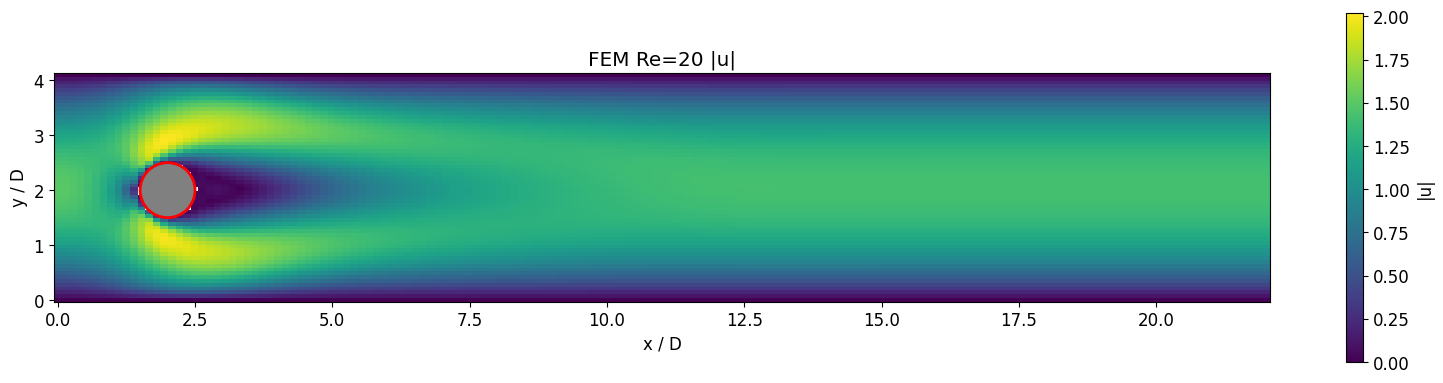

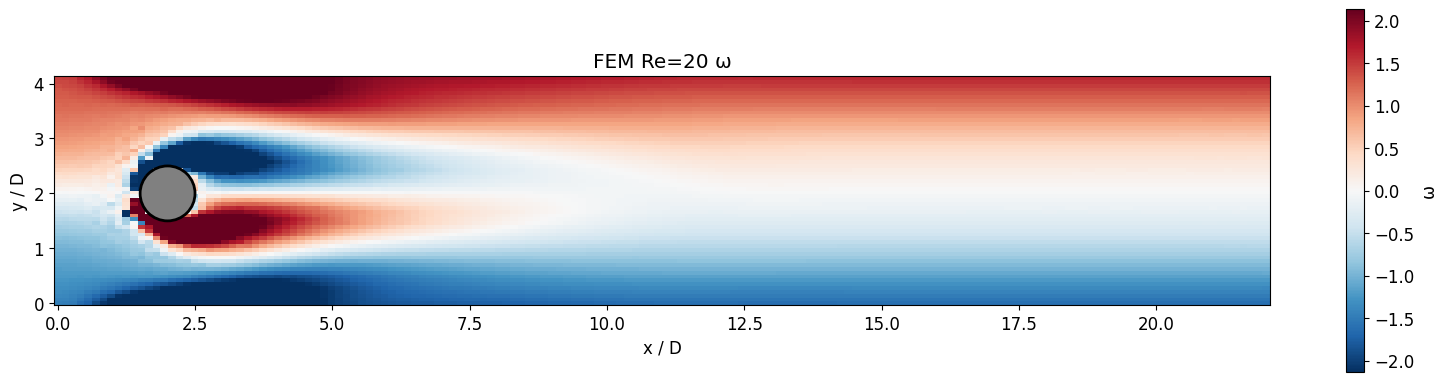

=== LBM Re=20 ===
  [LBM-BGK] Re=20, τ=0.7880, Ma=0.1039, grid=705×132
  [LBM] Warming up JIT (first call triggers compilation)...
  [LBM] JIT ready.
  [LBM] t*=1.00, max|ρ-1|=4.33e-02, KE=197.1
  [LBM] t*=2.00, max|ρ-1|=5.34e-02, KE=197.3
  [LBM] t*=3.00, max|ρ-1|=6.10e-02, KE=199.4
  [LBM] t*=4.00, max|ρ-1|=7.04e-02, KE=206.0
  [LBM] t*=5.00, max|ρ-1|=8.26e-02, KE=223.0
  [LBM] t*=6.00, max|ρ-1|=8.72e-02, KE=222.3
  [LBM] t*=7.00, max|ρ-1|=9.30e-02, KE=220.8
  [LBM] t*=8.00, max|ρ-1|=9.74e-02, KE=217.9
  [LBM] t*=8.99, max|ρ-1|=1.01e-01, KE=210.2
  [LBM] t*=9.99, max|ρ-1|=1.02e-01, KE=199.8
  [LBM] t*=10.99, max|ρ-1|=1.07e-01, KE=198.2
  [LBM] t*=11.99, max|ρ-1|=1.11e-01, KE=198.7
  [LBM] t*=12.99, max|ρ-1|=1.14e-01, KE=201.5
  [LBM] t*=13.99, max|ρ-1|=1.18e-01, KE=209.3
  [LBM] t*=14.99, max|ρ-1|=1.22e-01, KE=214.5
  [LBM] t*=15.99, max|ρ-1|=1.24e-01, KE=216.2
  [LBM] t*=16.99, max|ρ-1|=1.27e-01, KE=215.3
  [LBM] t*=17.99, max|ρ-1|=1.28e-01, KE=211.9
  [LBM] Done: 9600 steps in 19.2

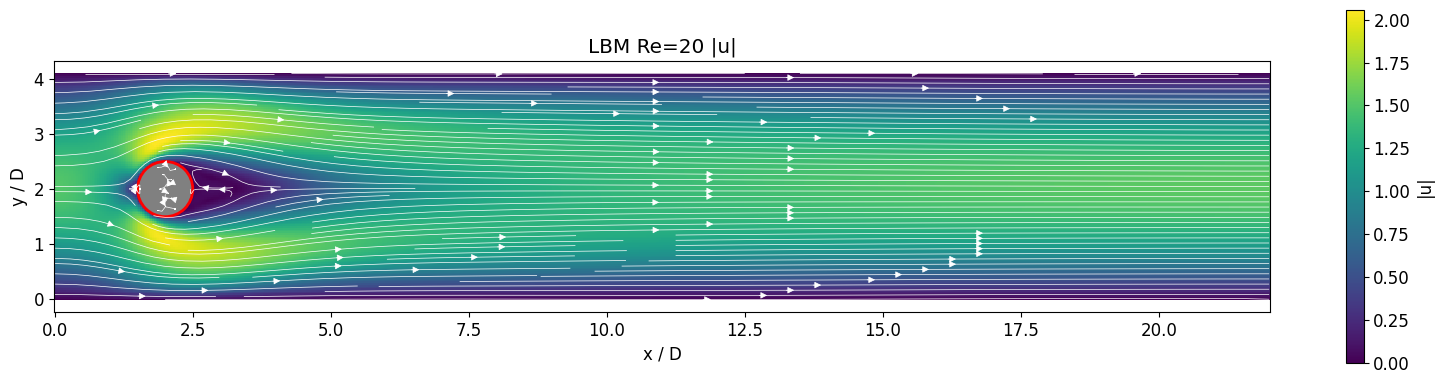

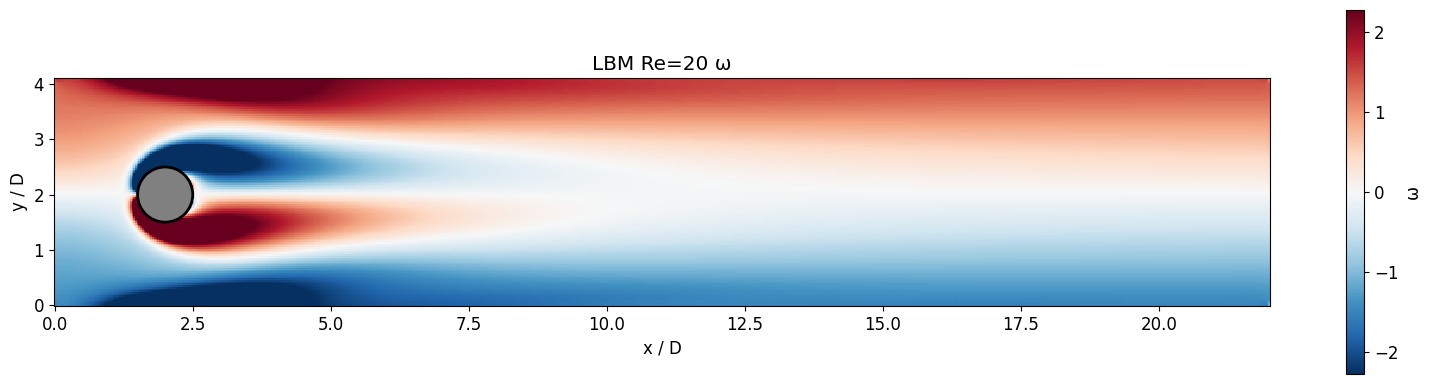

In [333]:
cfg_20 = CaseConfig(Re=20)

# --- 1) Finite difference ---
print("=== FD Re=20 ===")
res_fd_20 = run_fd_simulation(cfg_20, Nx=200, Ny=38, T_end=12.0, verbose=True)
om20 = compute_vorticity(res_fd_20["u"], res_fd_20["v"], res_fd_20["dx"], res_fd_20["dy"])
plot_velocity_field(res_fd_20["X"], res_fd_20["Y"], res_fd_20["u"], res_fd_20["v"],
                    title="FD Re=20 |u|", cfg=cfg_20)
plot_vorticity(res_fd_20["X"], res_fd_20["Y"], om20, title="FD Re=20 ω", cfg=cfg_20)

# --- 2) Finite element (NGSolve) ---

print("=== FEM Re=20 ===")
res_fem_20 = run_fem_simulation(cfg_20, maxh=0.28, T_end=8.0, dt=0.02, verbose=True)
plot_fem_velocity_field(res_fem_20, cfg_20, title="FEM Re=20 |u|")
plot_fem_vorticity(res_fem_20, cfg_20, title="FEM Re=20 ω")


# --- 3) Lattice Boltzmann ---
print("=== LBM Re=20 ===")
res_lbm_20 = run_lbm_simulation(cfg_20, D_lat=32, U_lat=0.06, T_star=18.0, verbose=True)
dx_l = float(res_lbm_20["X"][0, 1] - res_lbm_20["X"][0, 0])
dy_l = float(res_lbm_20["Y"][1, 0] - res_lbm_20["Y"][0, 0])
om_lbm = compute_vorticity(res_lbm_20["ux"], res_lbm_20["uy"], dx_l, dy_l)
plot_velocity_field(res_lbm_20["X"], res_lbm_20["Y"], res_lbm_20["ux"], res_lbm_20["uy"],
                    title="LBM Re=20 |u|", cfg=cfg_20)
plot_vorticity(res_lbm_20["X"], res_lbm_20["Y"], om_lbm, title="LBM Re=20 ω", cfg=cfg_20)


---
## 5b. Re = 100 Unsteady Validation

Periodic vortex shedding should be visible for all three methods. We extract the
**Strouhal number** St = f·D/U from the lift time-series via FFT 


=== FD Re=100 ===
  [FD] t=2.00, CFL=0.250, max|div_post|=3.33e+01, KE=54.9707, u_max=2.247
  [FD] t=4.00, CFL=0.250, max|div_post|=3.26e+01, KE=55.4725, u_max=2.086
  [FD] t=6.00, CFL=0.250, max|div_post|=3.39e+01, KE=55.5400, u_max=2.150
  [FD] t=8.00, CFL=0.250, max|div_post|=3.33e+01, KE=55.3403, u_max=2.046
  [FD] t=10.00, CFL=0.250, max|div_post|=3.47e+01, KE=54.9474, u_max=2.081
  [FD] t=12.00, CFL=0.250, max|div_post|=3.42e+01, KE=54.4166, u_max=1.992
  [FD] t=14.00, CFL=0.250, max|div_post|=3.54e+01, KE=53.7163, u_max=2.010
  [FD] t=16.00, CFL=0.250, max|div_post|=3.52e+01, KE=52.7339, u_max=1.932
  [FD] t=18.00, CFL=0.250, max|div_post|=3.62e+01, KE=51.6712, u_max=1.941
  [FD] t=20.00, CFL=0.250, max|div_post|=3.62e+01, KE=50.2860, u_max=1.879
  [FD] t=22.00, CFL=0.250, max|div_post|=3.70e+01, KE=48.8360, u_max=1.868
  [FD] t=24.00, CFL=0.250, max|div_post|=3.71e+01, KE=47.3912, u_max=1.835
  [FD] t=26.00, CFL=0.250, max|div_post|=3.77e+01, KE=46.1534, u_max=1.802
  [FD] t=28

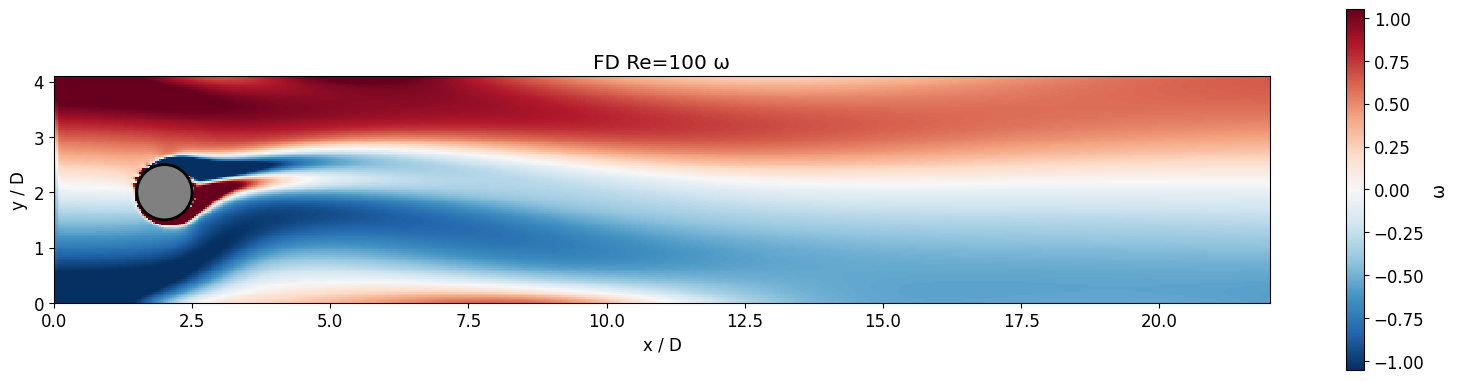

  FD  St = 0.0146


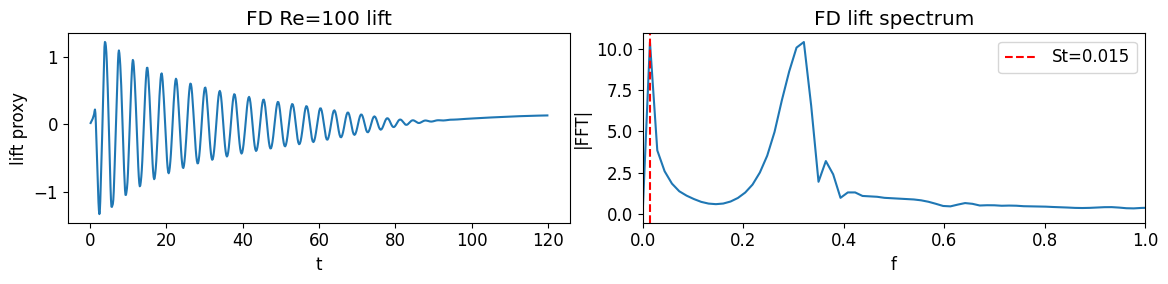

=== FEM Re=100 ===
  [FEM] t=1.00, KE=48.4690
  [FEM] t=2.00, KE=49.9383
  [FEM] t=3.00, KE=51.1848
  [FEM] t=4.00, KE=52.2111
  [FEM] t=5.00, KE=53.0766
  [FEM] t=6.00, KE=53.8190
  [FEM] t=7.00, KE=54.4636
  [FEM] t=8.00, KE=55.0267
  [FEM] t=9.00, KE=55.5193
  [FEM] t=10.00, KE=55.9499
  [FEM] t=11.00, KE=56.3295
  [FEM] t=12.00, KE=56.6651
  [FEM] t=13.00, KE=56.9632
  [FEM] t=14.00, KE=57.2332
  [FEM] t=15.00, KE=57.4864
  [FEM] t=16.00, KE=57.7308
  [FEM] t=17.00, KE=57.9751
  [FEM] t=18.00, KE=58.2270
  [FEM] t=19.00, KE=58.4908
  [FEM] t=20.00, KE=58.7606
  [FEM] t=21.00, KE=59.0282
  [FEM] t=22.00, KE=59.2966
  [FEM] t=23.00, KE=59.5272
  [FEM] t=24.00, KE=59.7130
  [FEM] t=25.00, KE=59.7997
  [FEM] t=26.00, KE=59.9007
  [FEM] t=27.00, KE=59.9706
  [FEM] t=28.00, KE=60.0402
  [FEM] t=29.00, KE=60.1676
  [FEM] t=30.00, KE=60.2344
  [FEM] t=31.00, KE=60.2708
  [FEM] t=32.00, KE=60.3426
  [FEM] t=33.00, KE=60.3466
  [FEM] t=34.00, KE=60.3890
  [FEM] t=35.00, KE=60.4346
  [FEM] t=

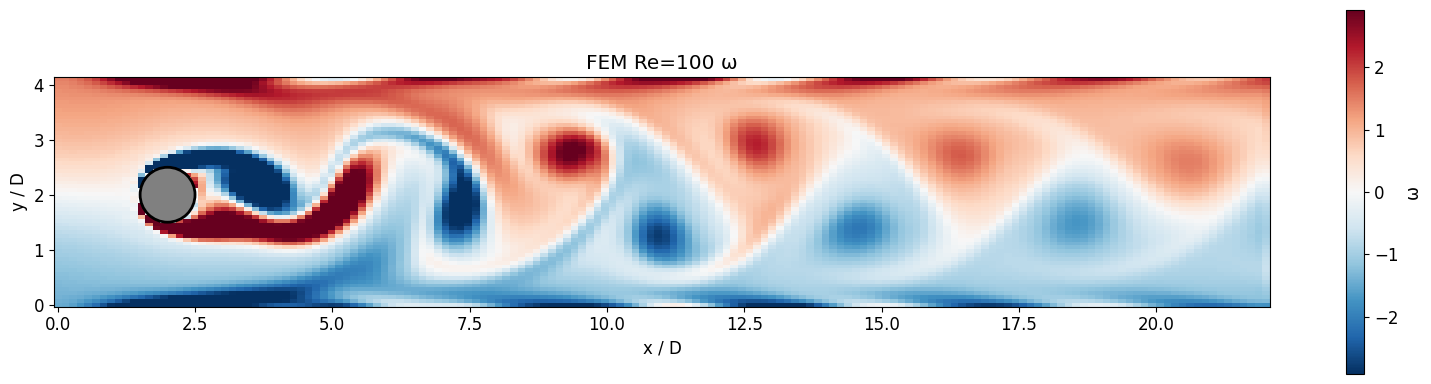

  FEM St = 0.3000


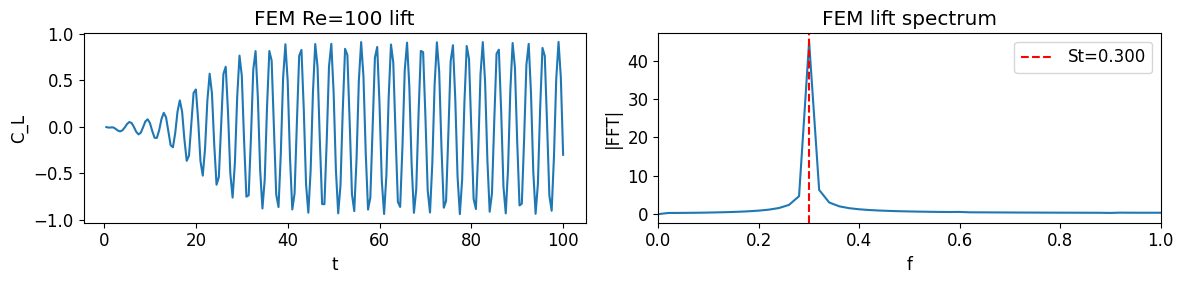

=== LBM Re=100 ===
  [LBM-BGK] Re=100, τ=0.5750, Ma=0.0866, grid=1101×205
  [LBM] Warming up JIT (first call triggers compilation)...
  [LBM] JIT ready.
  [LBM] t*=2.00, max|ρ-1|=3.97e-02, KE=352.2
  [LBM] t*=4.00, max|ρ-1|=5.67e-02, KE=381.2
  [LBM] t*=6.00, max|ρ-1|=5.53e-02, KE=369.8
  [LBM] t*=8.00, max|ρ-1|=6.07e-02, KE=355.1
  [LBM] t*=10.00, max|ρ-1|=6.72e-02, KE=367.0
  [LBM] t*=12.00, max|ρ-1|=7.45e-02, KE=380.8
  [LBM] t*=14.00, max|ρ-1|=7.66e-02, KE=375.8
  [LBM] t*=16.00, max|ρ-1|=7.78e-02, KE=368.6
  [LBM] t*=18.00, max|ρ-1|=8.29e-02, KE=373.8
  [LBM] t*=20.00, max|ρ-1|=8.77e-02, KE=380.8
  [LBM] t*=22.00, max|ρ-1|=8.88e-02, KE=380.5
  [LBM] t*=24.00, max|ρ-1|=8.97e-02, KE=378.3
  [LBM] t*=26.00, max|ρ-1|=9.28e-02, KE=377.8
  [LBM] t*=28.00, max|ρ-1|=9.53e-02, KE=379.4
  [LBM] t*=30.00, max|ρ-1|=9.68e-02, KE=381.9
  [LBM] t*=32.00, max|ρ-1|=9.82e-02, KE=380.5
  [LBM] t*=34.00, max|ρ-1|=9.97e-02, KE=379.0
  [LBM] t*=36.00, max|ρ-1|=1.01e-01, KE=379.9
  [LBM] t*=38.00, max|ρ

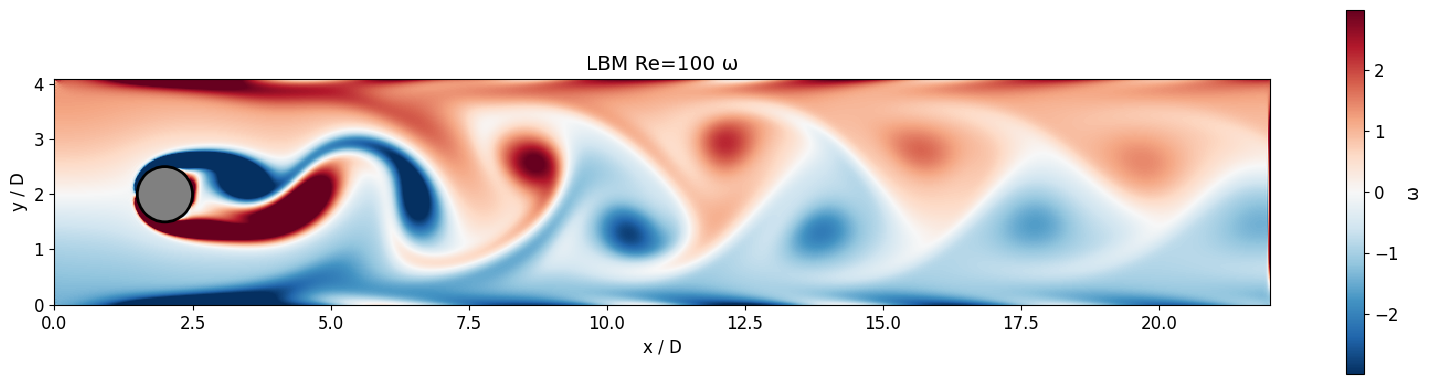

  LBM St = 0.3036


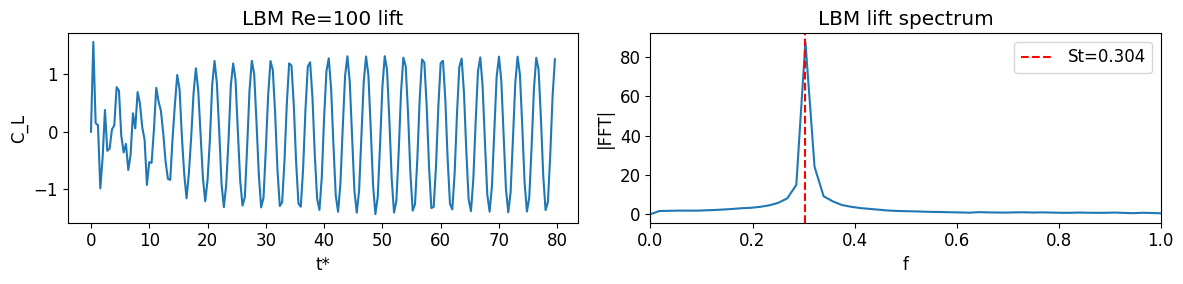


Blockage ratio D/H = 0.2439

Strouhal comparison at Re=100
DFG reference (blocked channel, D/H=0.244): St = 0.295–0.305
  Method   St         vs DFG
  FD     N/A        steady wake (Re_eff < onset)
  FEM    0.3000     +0.0%  PASS
  LBM    0.3036     +1.2%  PASS


In [334]:
cfg_100 = CaseConfig(Re=100)

# ── 1) FD at Re=100 ───────────────────────────────────────
print("=== FD Re=100 ===")
res_fd_100 = run_fd_simulation(cfg_100, Nx=660, Ny=123, T_end=120.0, save_every_t=2.0, verbose=True)
om100_fd   = compute_vorticity(res_fd_100["u"], res_fd_100["v"], res_fd_100["dx"], res_fd_100["dy"])
plot_vorticity(res_fd_100["X"], res_fd_100["Y"], om100_fd, title="FD Re=100 ω", cfg=cfg_100)

fd_diag = res_fd_100["diagnostics"]
St_fd = None
if len(fd_diag["time"]) > 5:
    St_fd, f_fd, freq_fd, fft_fd = extract_strouhal(fd_diag["time"], fd_diag["lift_proxy"], transient_fraction=0.5)
    print(f"  FD  St = {St_fd:.4f}" if St_fd else "  FD  insufficient data for St")
    fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    ax[0].plot(fd_diag["time"], fd_diag["lift_proxy"]); ax[0].set(xlabel="t", ylabel="lift proxy", title="FD Re=100 lift")
    if St_fd:
        ax[1].plot(freq_fd, fft_fd); ax[1].axvline(f_fd, c='r', ls='--', label=f"St={St_fd:.3f}")
        ax[1].set(xlabel="f", ylabel="|FFT|", title="FD lift spectrum", xlim=(0,1)); ax[1].legend()
    plt.tight_layout(); plt.show()

# ── 2) FEM at Re=100 ──────────────────────────────────────
print("=== FEM Re=100 ===")
res_fem_100 = run_fem_simulation(cfg_100, maxh=0.06, dt=0.002, T_end=100.0, save_every_t=1.0, verbose=True)
plot_fem_vorticity(res_fem_100, cfg_100, title="FEM Re=100 ω")

fem_diag = res_fem_100["diagnostics"]
St_fem = None
if len(fem_diag["time"]) > 5:
    St_fem, f_fem, freq_fem, fft_fem = extract_strouhal(fem_diag["time"], fem_diag["lift"], transient_fraction=0.5)
    print(f"  FEM St = {St_fem:.4f}" if St_fem else "  FEM insufficient data for St")
    fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    ax[0].plot(fem_diag["time"], fem_diag["lift"]); ax[0].set(xlabel="t", ylabel="C_L", title="FEM Re=100 lift")
    if St_fem:
        ax[1].plot(freq_fem, fft_fem); ax[1].axvline(f_fem, c='r', ls='--', label=f"St={St_fem:.3f}")
        ax[1].set(xlabel="f", ylabel="|FFT|", title="FEM lift spectrum", xlim=(0,1)); ax[1].legend()
    plt.tight_layout(); plt.show()

# ── 3) LBM at Re=100 ──────────────────────────────────────
print("=== LBM Re=100 ===")
res_lbm_100 = run_lbm_simulation(cfg_100, D_lat=50, U_lat=0.05, T_star=80.0, save_every_t=2.0, verbose=True)
dx_l = float(res_lbm_100["X"][0,1] - res_lbm_100["X"][0,0])
dy_l = float(res_lbm_100["Y"][1,0] - res_lbm_100["Y"][0,0])
om_lbm_100 = compute_vorticity(res_lbm_100["ux"], res_lbm_100["uy"], dx_l, dy_l)
plot_vorticity(res_lbm_100["X"], res_lbm_100["Y"], om_lbm_100, title="LBM Re=100 ω", cfg=cfg_100)

lbm_diag = res_lbm_100["diagnostics"]
St_lbm = None
if len(lbm_diag["time_star"]) > 5:
    St_lbm, f_lbm, freq_lbm, fft_lbm = extract_strouhal(lbm_diag["time_star"], lbm_diag["lift_proxy"])
    print(f"  LBM St = {St_lbm:.4f}" if St_lbm else "  LBM insufficient data for St")
    fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    ax[0].plot(lbm_diag["time_star"], lbm_diag["lift_proxy"]); ax[0].set(xlabel="t*", ylabel="C_L", title="LBM Re=100 lift")
    if St_lbm:
        ax[1].plot(freq_lbm, fft_lbm); ax[1].axvline(f_lbm, c='r', ls='--', label=f"St={St_lbm:.3f}")
        ax[1].set(xlabel="f", ylabel="|FFT|", title="LBM lift spectrum", xlim=(0,1)); ax[1].legend()
    plt.tight_layout(); plt.show()

# ── Strouhal comparison table ──────────────────────────────
print(f"\nBlockage ratio D/H = {cfg_100.cyl_radius * 2 / cfg_100.H:.4f}")
print("\nStrouhal comparison at Re=100")
print("DFG reference (blocked channel, D/H=0.244): St = 0.295–0.305")
print(f"  {'Method':<8} {'St':<10} {'vs DFG'}")
ref_St = 0.300
for name, St in [("FD", St_fd), ("FEM", St_fem), ("LBM", St_lbm)]:
    if St and St > 0.05:
        err = (St - ref_St) / ref_St * 100
        flag = "PASS" if 0.28 < St < 0.32 else "CHECK"
        print(f"  {name:<6} {St:.4f}     {err:+.1f}%  {flag}")
    else:
        print(f"  {name:<6} N/A        steady wake (Re_eff < onset)")


---
## 6. Re sweep (short)

Increase `Re` until a method fails (`stable=False`). Tighten `T_end` / grids for a quick scan.


In [335]:
Re_vals = [20, 40, 60, 80, 100, 150, 200, 300, 500]

# Resolution targets matched at ~25-30 cells across cylinder diameter (D=1):
#   FD:  Ny=41 → dy=H/Ny≈0.100,  D/dy≈10  (comparable to D_lat=30 for coarse sweep)
#   LBM: D_lat=30
#   FEM: maxh≈0.05 near cylinder
T_conv = 50.0  # same end time in convective units for all methods

fd_results  = {}
lbm_results = {}
fem_results = {}

# ── FD sweep ──────────────────────────────────────────────
print("FD sweep")
print(f"{'Re':<5} {'Grid':<12} {'Wall[s]':<9} {'Stable':<8} {'St':}")
for Re in Re_vals:
    c = CaseConfig(Re=Re)
    r = run_fd_simulation(c, Nx=220, Ny=41, T_end=T_conv, verbose=False)
    fd_results[Re] = r
    diag = r['diagnostics']
    St_val, *_ = extract_strouhal(diag['time'], diag['lift_proxy']) if len(diag['time']) > 5 else (None,)*4
    St_s = f"{St_val:.3f}" if St_val else "N/A"
    print(f"  {Re:<3}  220x41       {r['wall_time']:<9.1f} {str(r['stable']):<8} {St_s}")

# ── LBM sweep ─────────────────────────────────────────────
print("\nLBM sweep")
print(f"{'Re':<5} {'Grid':<16} {'tau':<7} {'Wall[s]':<9} {'Stable':<8} {'St':}")
for Re in Re_vals:
    c = CaseConfig(Re=Re)
    r = run_lbm_simulation(c, D_lat=30, U_lat=0.05, T_star=T_conv, verbose=False)
    lbm_results[Re] = r
    diag = r['diagnostics']
    St_val, *_ = extract_strouhal(diag['time_star'], diag['lift_proxy']) if len(diag['time_star']) > 5 else (None,)*4
    St_s = f"{St_val:.3f}" if St_val else "N/A"
    print(f"  {Re:<3}  {r['Nx']}x{r['Ny']:<9}  {r['params']['tau']:.4f}  {r['wall_time']:<9.1f} {str(r['stable']):<8} {St_s}")

# ── FEM sweep ─────────────────────────────────────────────
print("\nFEM sweep")
Re_fem_sweep = [20, 40, 60, 100, 150, 200, 300]
print(f"{'Re':<5} {'maxh':<8} {'DOF':>8}  {'Wall[s]':<9} {'Stable':<8} {'St'}")
for Re in Re_fem_sweep:
    c = CaseConfig(Re=Re)
    # Higher Re needs longer run to reach settled shedding; keep dt tight for stability
    T_fem = max(T_conv, 80.0) if Re >= 100 else T_conv
    r = run_fem_simulation(c, maxh=0.15, dt=0.005, T_end=T_fem,
                           save_every_t=1.0, verbose=False)
    fem_results[Re] = r
    diag = r['diagnostics']
    # Discard first 40% as transient; at low Re signal may be steady (St=N/A expected)
    St_val, *_ = (extract_strouhal(diag['time'], diag['lift'], transient_fraction=0.4)
                  if len(diag['time']) > 5 else (None, None, None, None))
    St_s  = f"{St_val:.3f}" if St_val else "N/A"
    ndof  = r['gfu'].space.ndof if r.get('stable') and r.get('gfu') else 0
    print(f"  {Re:<3}  0.15     {ndof:>8}  {r['wall_time']:<9.1f} {str(r['stable']):<8} {St_s}")

# ── Summary: stability limits ──────────────────────────────
print("\n" + "="*60)
print("Stability limits (first Re to fail):")
for name, rd, Re_list in [("FD",  fd_results,  Re_vals),
                           ("LBM", lbm_results, Re_vals),
                           ("FEM", fem_results, [20,60,100,200,300])]:
    unstable = [Re for Re in Re_list if not rd.get(Re, {}).get('stable', True)]
    limit = str(min(unstable)) if unstable else f"> {max(Re_list)}"
    print(f"  {name}: first failure at Re = {limit}")


FD sweep
Re    Grid         Wall[s]   Stable   St
  20   220x41       2.6       True     0.031
  40   220x41       2.2       True     0.027
  60   220x41       2.2       True     0.205
  80   220x41       2.4       True     0.206
  100  220x41       2.5       True     0.233
  150  220x41       2.9       True     0.240
  200  220x41       3.2       True     0.271
  300  220x41       3.5       True     0.274
  500  220x41       3.7       True     0.249

LBM sweep
Re    Grid             tau     Wall[s]   Stable   St
  20   661x123        0.7250  55.7      True     1.143
  40   661x123        0.6125  55.8      True     0.286
  60   661x123        0.5750  55.6      True     0.286
  80   661x123        0.5563  53.6      True     0.314
  100  661x123        0.5450  55.2      True     0.314
  150  661x123        0.5300  0.9       False    N/A
  200  661x123        0.5225  0.5       False    N/A
  300  661x123        0.5150  0.4       False    N/A
  500  661x123        0.5090  0.4       False  

---
## 8. Resolution Study at Re = 100

Fix Re = 100 and compare Strouhal number and mean drag at two resolution levels
for each method, to assess convergence behaviour.


In [336]:
cfg_res = CaseConfig(Re=100)
T_res   = 60.0

print(f"{'Method':<12} {'Resolution':<22} {'Wall[s]':<10} {'St':<8} {'Mean C_D'}")

# ── FD ────────────────────────────────────────────────────
for label, Nx_r, Ny_r in [("FD-coarse", 200, 38), ("FD-fine", 440, 82)]:
    r    = run_fd_simulation(cfg_res, Nx=Nx_r, Ny=Ny_r, T_end=T_res, verbose=False)
    diag = r['diagnostics']
    St_r, *_ = extract_strouhal(diag['time'], diag['lift_proxy']) if len(diag['time']) > 5 else (None,)*4
    cd_mean  = float(np.mean(diag['drag_proxy'][-20:])) if diag['drag_proxy'] else float('nan')
    print(f"  {label:<12} {Nx_r}x{Ny_r} (D/dy≈{1.0/r['dy']:.0f})   {r['wall_time']:<10.1f} {str(St_r)[:6]:<8} {cd_mean:.4f}")

# ── LBM ───────────────────────────────────────────────────
for label, D_r, U_r in [("LBM-coarse", 30, 0.05), ("LBM-fine", 60, 0.05)]:
    r    = run_lbm_simulation(cfg_res, D_lat=D_r, U_lat=U_r, T_star=T_res, verbose=False)
    diag = r['diagnostics']
    St_r, *_ = extract_strouhal(diag['time_star'], diag['lift_proxy']) if len(diag['time_star']) > 5 else (None,)*4
    cd_mean  = float(np.mean(diag['drag_proxy'][-20:])) if diag['drag_proxy'] else float('nan')
    print(f"  {label:<12} D={D_r} ({r['Nx']}x{r['Ny']})  {r['wall_time']:<10.1f} {str(St_r)[:6]:<8} {cd_mean:.4f}")

# ── FEM ───────────────────────────────────────────────────
for label, mh_r, ddt_r in [("FEM-coarse", 0.25, 0.01), ("FEM-fine", 0.12, 0.005)]:
    r    = run_fem_simulation(cfg_res, maxh=mh_r, T_end=min(T_res, 30.0), dt=ddt_r, verbose=False)
    diag = r['diagnostics']
    St_r, *_ = extract_strouhal(diag['time'], diag['lift']) if len(diag['time']) > 5 else (None,)*4
    cd_mean  = float(np.mean(diag['drag'][-20:])) if diag.get('drag') else float('nan')
    print(f"  {label:<12} maxh={mh_r}            {r['wall_time']:<10.1f} {str(St_r)[:6]:<8} {cd_mean:.4f}")


Method       Resolution             Wall[s]    St       Mean C_D
  FD-coarse    200x38 (D/dy≈9)   2.1        0.2163   -11205.0200
  FD-fine      440x82 (D/dy≈20)   24.5       0.2393   -27155.6535
  LBM-coarse   D=30 (661x123)  175.1      0.3095   9.0258
  LBM-fine     D=60 (1321x246)  675.3      0.3095   6.3505
  FEM-coarse   maxh=0.25            28.5       0.2857   2.1921
  FEM-fine     maxh=0.12            826.5      0.2857   2.2847


--- ## 10. BGK vs MRT Stability Comparison

Demonstrating that MRT — with **identical lattice, BCs, and equilibrium** to BGK —
extends the stable Re range by independently damping non-hydrodynamic ghost modes.

- **Controlled variable:** only the collision operator changes.
- **Metric:** highest Re at which the method completes `T*` without NaN/ρ < 0.
- **Expected:** MRT stable to ~2–3× higher Re than BGK at the same D_lat.

**Why MRT helps:** BGK forces all 9 moments to relax at ω = 1/τ.
When τ → 0.5 (high Re), ghost modes oscillate instead of damping.
MRT relaxes ghost modes at s_ghost ≈ 1.1 regardless of τ, keeping them stable.

In [344]:
# === BGK vs MRT stability comparison ======================================
print("=" * 62)
print("BGK vs MRT stability comparison")
print("=" * 62)

D_lat_cmp  = 50
U_lat_cmp  = 0.04
T_star_cmp = 30.0   # short enough to be fast, long enough to catch instability

Re_vals_cmp = [100, 200, 300, 450, 500, 700, 1000]


print(f"\nGrid: D_lat={D_lat_cmp}, U_lat={U_lat_cmp}, T*={T_star_cmp}")
print(f"{'Re':<6} {'tau':>8} {'BGK':>10} {'MRT':>10} "
      f"{'BGK t(s)':>10} {'MRT t(s)':>10}")
print("-" * 62)

for Re_cmp in Re_vals_cmp:
    cfg_cmp = CaseConfig(Re=Re_cmp)
    p_cmp   = lattice_params(Re_cmp, D_lat_cmp, U_lat_cmp)

    r_bgk = run_lbm_simulation(cfg_cmp, D_lat=D_lat_cmp, U_lat=U_lat_cmp,
                                T_star=T_star_cmp, collision='bgk', verbose=False)
    r_mrt = run_lbm_simulation(cfg_cmp, D_lat=D_lat_cmp, U_lat=U_lat_cmp,
                                T_star=T_star_cmp, collision='mrt', verbose=False)

    print(f"{Re_cmp:<6} {p_cmp['tau']:>8.5f} "
          f"{'STABLE' if r_bgk['stable'] else 'BROKE':>10} "
          f"{'STABLE' if r_mrt['stable'] else 'BROKE':>10} "
          f"{r_bgk['wall_time']:>9.1f}s "
          f"{r_mrt['wall_time']:>9.1f}s")




BGK vs MRT stability comparison

Grid: D_lat=50, U_lat=0.04, T*=30.0
Re          tau        BGK        MRT   BGK t(s)   MRT t(s)
--------------------------------------------------------------
100     0.56000     STABLE     STABLE     173.8s     304.3s
200     0.53000      BROKE     STABLE       1.4s     307.5s
300     0.52000      BROKE     STABLE       1.0s     304.7s
450     0.51333      BROKE     STABLE       1.0s     303.9s
500     0.51200      BROKE      BROKE       1.0s     235.6s
700     0.50857      BROKE      BROKE       1.1s     249.8s
1000    0.50600      BROKE      BROKE       1.0s     236.3s
